<a href="https://colab.research.google.com/github/Jorgeberlin/pricing_library/blob/main/proyecto_met_num_y_sim_est.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos Quasi-Newton: BFGS y L-BFGS
### Proyecto Final — Métodos Numéricos y Simulación Estocástica
**Autores:** Lara Martínez Daniela, Peñaranda Berlín Jorge  
**Fecha:** Mayo 2026

---

> **Resumen:** Este notebook investiga los métodos quasi-Newton BFGS y L-BFGS para optimización no lineal. Partiendo del gradient descent con búsqueda de línea, derivamos la familia de métodos quasi-Newton, implementamos BFGS desde cero y L-BFGS usando librerías, y los evaluamos experimentalmente sobre funciones de prueba estándar y problemas de calibración financiera.


## Tabla de contenidos

1. [Contexto y motivación](#1)

2. [Fundamento teórico](#2)  CREO QUE PODEMOS QUITAR LA SEPAPRACION TEORIA-IMPLEMENTACION Y HACERLO TODO MÁS "SEGUIDO"
   - 2.1 Gradient Descent  
       - 2.1.1 Implementación básica  
       - 2.1.2 Limitaciones  
          - a) Sensibilidad al learning rate  
          - b) Convergencia lenta en problemas mal condicionados (valles estrechos)  AQUI METI TU CODIGO
          - c) Ausencia de información de curvatura  
          - d) Dependencia del punto inicial  
          - e) Ineficiencia en regímenes de alta precisión

   - 2.2 El método de Newton  
   - 2.3 La idea quasi-Newton  
   - 2.4 Derivación del método BFGS  
   - 2.5 Propiedades teóricas  
   - 2.6 L-BFGS: memoria limitada  

3. [Aplicación Financiera](#3)  
   - 3.1 Gradient Descent + Armijo (baseline)    SUP.VOL
   - 3.2 BFGS desde cero                         OPT.PORTF
   - 3.3 L-BFGS con SciPy  

4. [Conclusiones](#6)  

5. [Referencias](#7)

In [ ]:
# Imports globales
import numpy as np
import matplotlib.pyplot as plt

# Para mostrar las funciones de Desmos
from IPython.display import Image, display

# Para las implementaciones básicas de Gradient Descent (uso de funciones en JAX)
import jax.numpy as jnp
from jax import grad

# Para la implementación de Newton y siguientes necesitamos el Hessiano
from jax import hessian

# Sin usar
import scipy.optimize as opt
from dataclasses import dataclass, field
from typing import Callable, Optional
import time
import warnings

# Filtro de Warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

SEED = 1
np.random.seed(SEED)
print('Entorno listo')

Entorno listo


---

## <span style="color:#1f77b4">1. Contexto y motivación</span> <a id='2'></a>

---


*[Por completar]*

- Qué es un problema de optimización no lineal y dónde aparece en finanzas:
  - Calibración de modelos (Black-Scholes, Heston, Vasicek)
  - Optimización de cartera de Markowitz
- Por qué GD con Armijo no siempre es suficiente: convergencia lenta en funciones mal condicionadas
- Qué ofrece BFGS: convergencia superlineal, coste de primer orden, estándar industrial




---

## <span style="color:#1f77b4">2. Fundamento teórico</span> <a id='2'></a>

---

### 2.1 Gradient Descent

El método de gradient descent es el punto de partida natural para la optimización de funciones diferenciables.
Dada una función objetivo $f : \mathbb{R}^n \rightarrow \mathbb{R}$, la iteración básica es:

$$
x_{k+1} = x_k - \alpha_k \nabla f(x_k)
$$

donde:

$$
\begin{array}{ll}
\alpha_k > 0 & \text{es el tamaño de paso (step length)} \\
-\nabla f(x_k) & \text{es la dirección de máximo descenso local}
\end{array}
$$


La intuición es que en cada iteración, nos movemos en la dirección en que la función decrece más rápidamente. Por lo tanto, este algoritmo es muy dependiente del $\alpha$ inicial que se elija. Una elección inadecuada de $\alpha_k$ puede hacer que el algoritmo diverja (paso demasiado grande) o converja extremadamente lento (paso demasiado pequeño). El backtracking con condición de Armijo (también llamada condición de sufficient decrease) busca mitigar este problema.

### 2.1.1 Implementación básica

Mostramos una implementación inicial básica, minimizando una función convexa bien comportada:

$f(x, y) = 2x^2 + y^2 - 3x$

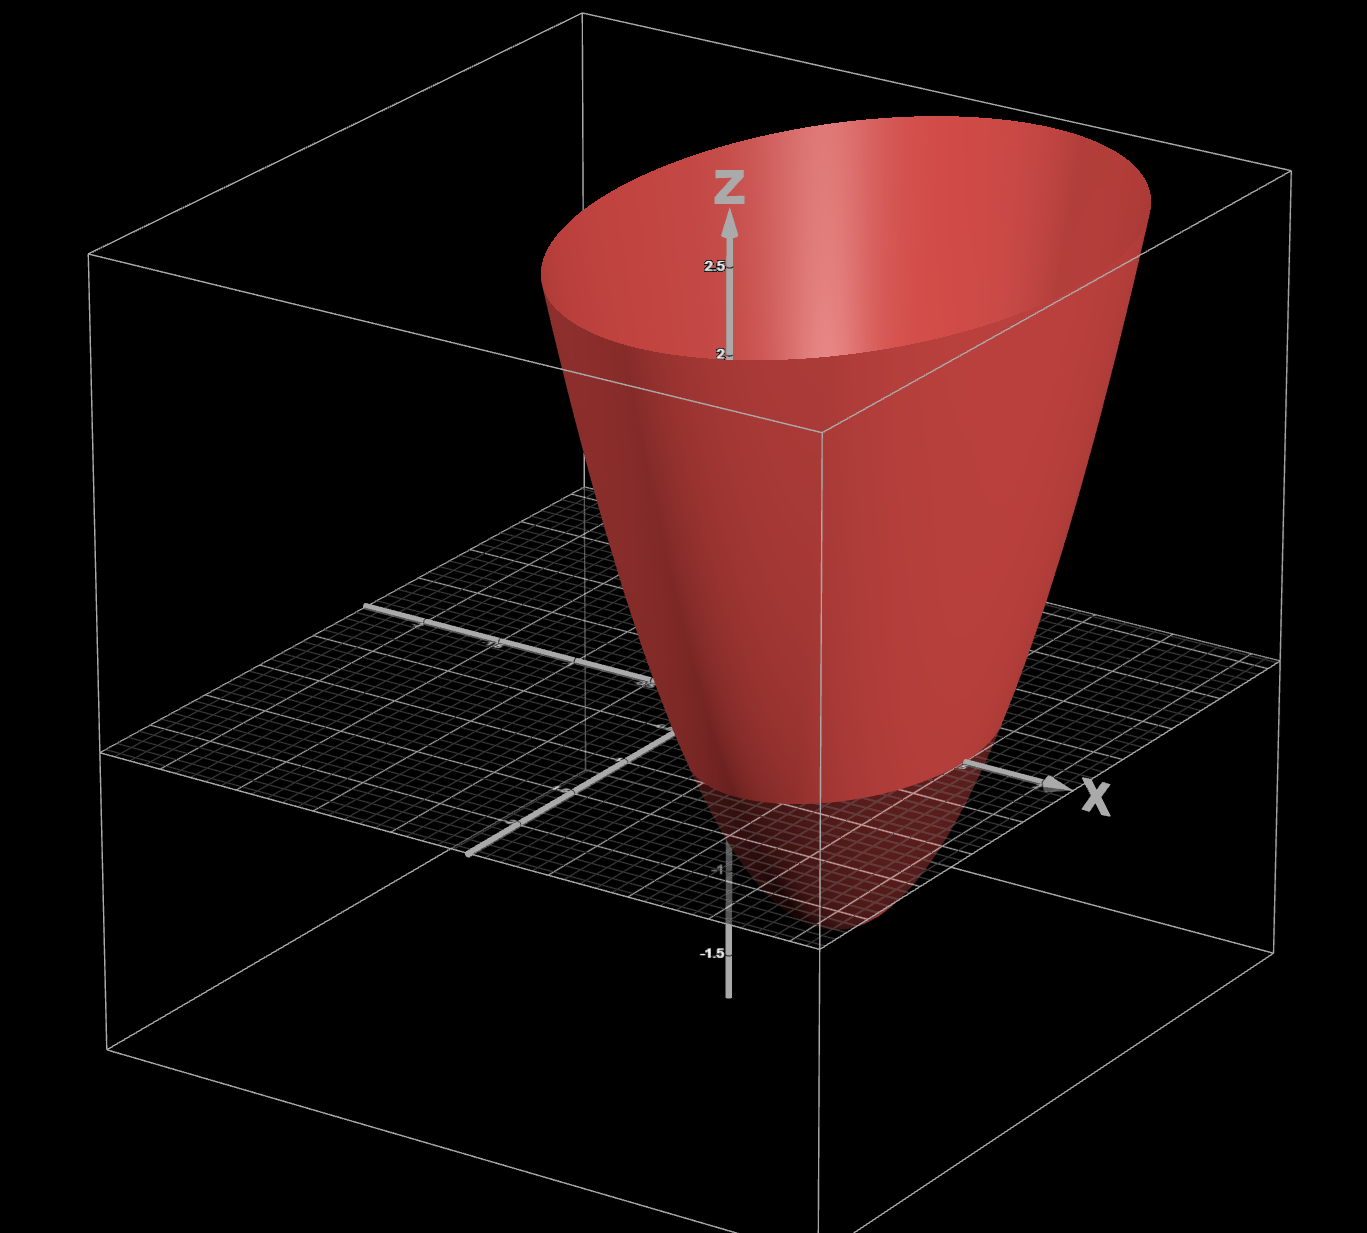

In [ ]:
display(Image(filename="Funcion_Convexa_1.png", width= 500, height=500))

In [ ]:
def descenso_por_gradiente_basico(
    f,
    x0,
    learning_rate=0.9,
    iteraciones=100,
    verbose=False
):
    x = x0

    history_x = []
    history_cost = []

    grad_f = grad(f)

    for i in range(iteraciones):
        g = grad_f(x)
        x = x - learning_rate * g
        cost = f(x)

        history_x.append(x)
        history_cost.append(cost)

        if verbose:
            print(
                f"Iteración {i+1}: "
                f"x = {x}, "
                f"coste = {cost}"
            )

    history_x = jnp.array(history_x)
    history_cost = jnp.array(history_cost)

    return x, history_x, history_cost

### 2.1.1 Limitaciones

### a) Sensibilidad extrema al Learning Rate

El factor $\alpha$ es el único parámetro del que tenemos control en este algoritmo. El problema es que, eligiendo un $\alpha$ muy pequeño, aún suponiendo que la función es bien comportada, corremos el riesgo de que el algoritmo tarde mucho en converger. Asimismo, un learning rate muy grande puede hacer que el algoritmo diverja (ejemplo más abajo):

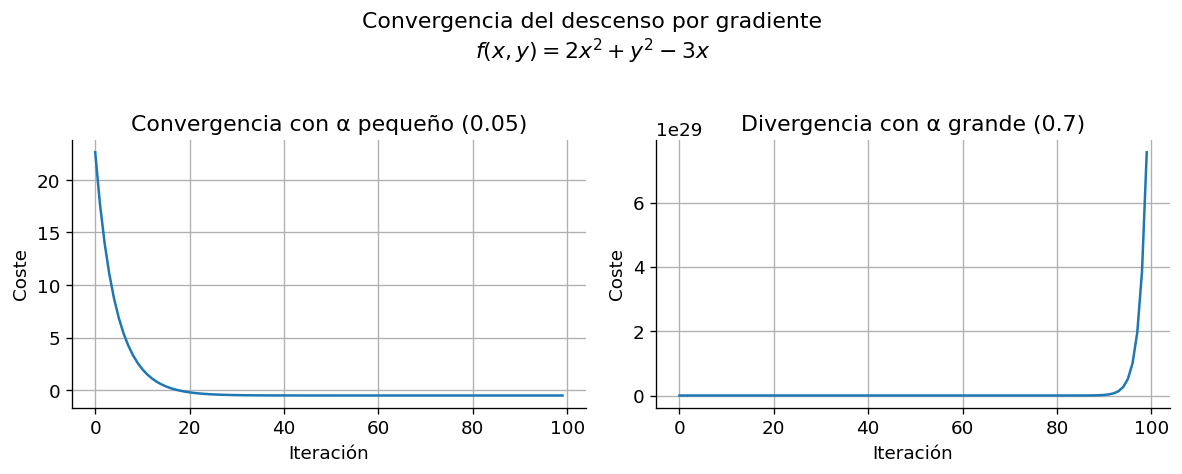

In [ ]:
# función objetivo
f = lambda x: 2*x[0]**2 + x[1]**2 - 2*x[0] # Aquí puse la misma función cuadrática de antes. Una función convexa bien comportada.
x0 = jnp.array([2.0, 5.0])


# ejecutar para dos alphas
_, _, cost_005 = descenso_por_gradiente_basico(
    f, x0, learning_rate=0.05
)

_, _, cost_07 = descenso_por_gradiente_basico(
    f, x0, learning_rate=0.6
)


# esto es para crear los dos gráficos en el mismo output y que los podamos comparar bien
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# alpha = 0.05
axes[0].plot(cost_005)
axes[0].set_title("Convergencia con α pequeño (0.05)")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Coste")
axes[0].grid(True)

# alpha = 0.9
axes[1].plot(cost_07)
axes[1].set_title("Divergencia con α grande (0.7)")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Coste")
axes[1].grid(True)

plt.suptitle(
    "Convergencia del descenso por gradiente\n"
    r"$f(x, y) = 2x^2 + y^2 - 3x$"
)

plt.tight_layout()
plt.show()

Para solucionar (parcialmente) este problema, se puede incluir la condición de Armijo.  
Esta condición exige que el paso aceptado produzca una reducción suficiente en $f$:

$$
f(x_k + \alpha_k p_k) \leq f(x_k) + c \alpha_k \nabla f_k^T p_k
$$

donde:

- $c \in (0,1)$ es una constante pequeña

- $p_k = -\nabla f(x_k)$ es la dirección de descenso

El procedimiento para seleccionar el $\alpha$ adecuado
es (Nocedal & Wright, 2006, p. 41):

1. Comenzar con un paso inicial $\bar{\alpha}$ (típicamente $\bar{\alpha} = 1$)
2. Si la condición de Armijo no se cumple, reducir $\alpha \leftarrow \rho \alpha$
   con $\rho \in (0,1)$
3. Repetir hasta que la condición se satisfaga

Esto garantiza que el paso nunca sea demasiado largo, y que tampoco sea
innecesariamente corto.


In [ ]:
def descenso_por_gradiente_con_armijo(
    f,
    x0,
    learning_rate=0.8,
    learning_rate_reduccion = 0.5,
    iteraciones=100,
    constante_de_armijo = 0.0001,
    verbose=False
):
    x = x0

    history_x = []
    history_cost = []

    grad_f = grad(f)

    for i in range(iteraciones):
        g = grad_f(x)
        p = -g
        while f(x + learning_rate * p) > (f(x) + constante_de_armijo * learning_rate * jnp.dot(g, p)):
          learning_rate *= learning_rate_reduccion
        x = x - learning_rate * g
        cost = f(x)

        history_x.append(x)
        history_cost.append(cost)

        if verbose:
            print(
                f"Iteración {i+1}: "
                f"x = {x}, "
                f"coste = {cost}"
            )

    history_x = jnp.array(history_x)
    history_cost = jnp.array(history_cost)

    return x, history_x, history_cost

In [ ]:
f = lambda x: 2*x[0]**2 + x[1]**2 - 2*x[0] # Misma función cuadrática
x0 = jnp.array([2.0, 5.0])
_, _, cost_armijo = descenso_por_gradiente_con_armijo(
    f, x0
)

# ===============================
# Gradient Descent básico
# ===============================

_, _, cost_basico = descenso_por_gradiente_basico(
    f,
    x0,
    learning_rate=0.05,
    iteraciones=50,
    verbose=False
)
# ===============================
# Gradient Descent con Armijo
# ===============================

_, _, cost_armijo = descenso_por_gradiente_con_armijo(
    f,
    x0,
    learning_rate=1.0,
    iteraciones=50,
    verbose=False
)

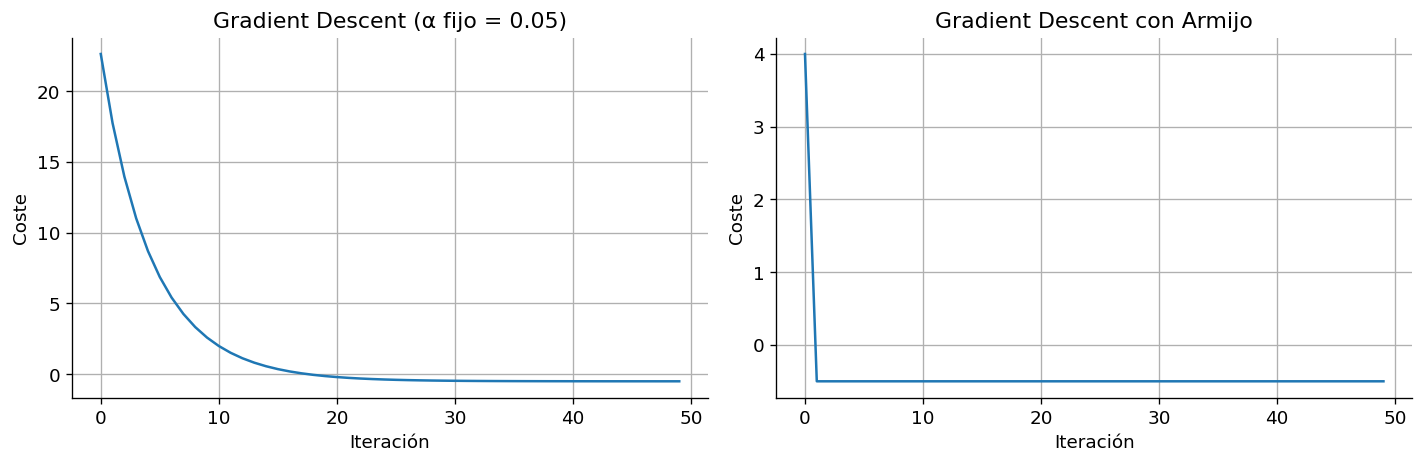

In [ ]:
# ===============================
# Plot comparativo
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- Sin Armijo
axes[0].plot(cost_basico)
axes[0].set_title("Gradient Descent (α fijo = 0.05)")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Coste")
axes[0].grid(True)

# ---- Con Armijo
axes[1].plot(cost_armijo)
axes[1].set_title("Gradient Descent con Armijo")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Coste")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Y con esto mostramos que con Armijo al menos puede mitigarse parcialmente este problema. Más adelante veremos cómo tratan otros métodos esta cuestión.

### b) Convergencia lenta en valles estrechos

El problema de este algoritmo es que, además, tiene problemas con funciones que
poseen "valles estrechos". Si una función es relativamente muy empinada en una dirección y plana en otra, esto puede forzar a que el paso oscile fuertemente
en la dirección empinada. Para visualizarlo, usamos Desmos para mostrar la misma función que antes, solo que ahora la estrechamos mucho en una de las direccciones:

$f(x, y) = 20x^2 + y^2 - 2x$



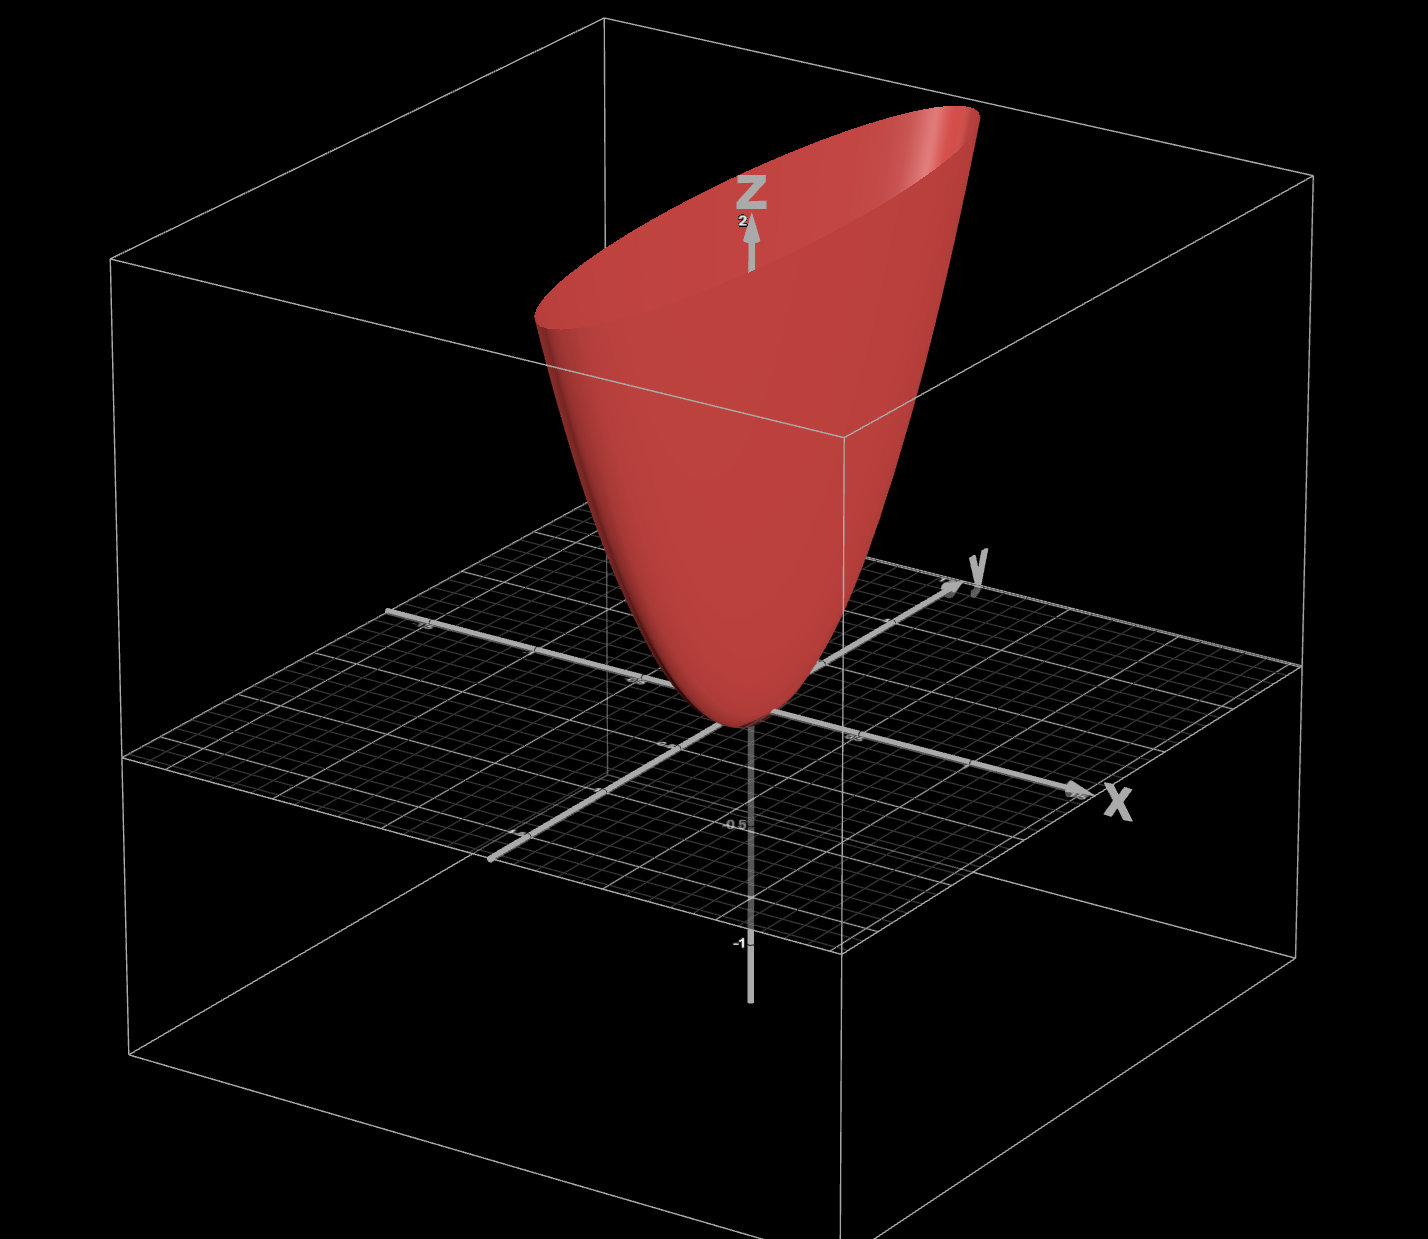

In [ ]:
display(Image(filename="Funcion_Convexa_2.png", width= 500, height=500))

Para esta función, tenemos que su Hessiana es:

\begin{bmatrix}
    40 & 0 \\
    0 & 2
\end{bmatrix}

Por lo que el factor $k$ será de 40/2 = 20
Observamos que para funciones de este estilo, el algoritmo, aunque elijamos un $\alpha$ adeacuado, puede tener tendencia a zigzagea:

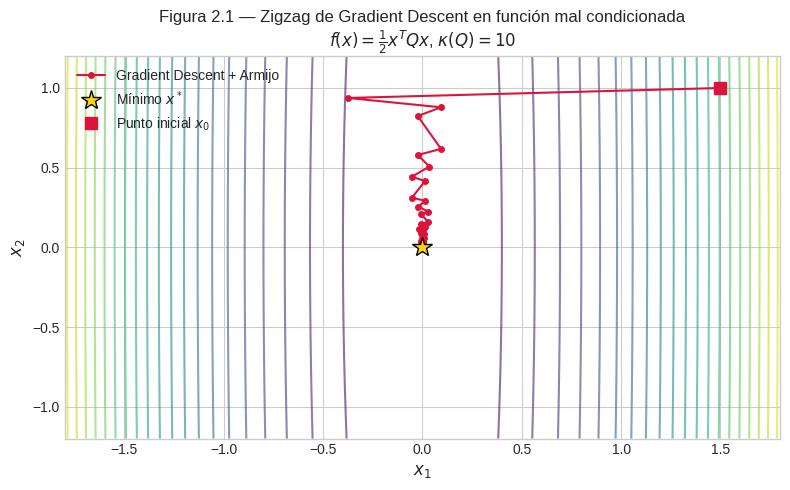

Iteraciones hasta convergencia: 50
Punto final: [0.00011149 0.00156335]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Definimos una función cuadrática mal condicionada
Q = np.array([[40, 0],
              [0,   2]])   # condición κ = 40/2 = 20

b = np.zeros(2)
x_star = np.zeros(2)  # mínimo en el origen

def f(x):
    return 0.5 * x @ Q @ x - b @ x

def grad_f(x):
    return Q @ x - b

# 2. Gradient Descent con Armijo (backtracking)
def gradient_descent_armijo(x0, n_iter=50, alpha_init=1.0, rho=0.5, c=1e-4):
    x = x0.copy()
    trayectoria = [x.copy()]

    for _ in range(n_iter):
        g = grad_f(x)
        p = -g  # dirección de descenso

        # reducir alpha hasta cumplir condición de Armijo
        alpha = alpha_init
        while f(x + alpha * p) > f(x) + c * alpha * g @ p:
            alpha *= rho

        x = x + alpha * p
        trayectoria.append(x.copy())

        if np.linalg.norm(g) < 1e-6:  # criterio de parada
            break

    return np.array(trayectoria)

# 3. Ejecutamos GD desde un punto inicial
x0 = np.array([1.5, 1.0])
tray = gradient_descent_armijo(x0, n_iter=50)

# 4. Graficamos contornos + trayectoria
fig, ax = plt.subplots(figsize=(8, 5))

# Contornos de f
x1 = np.linspace(-1.8, 1.8, 400)
x2 = np.linspace(-1.2, 1.2, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = 0.5 * (100 * X1**2 + X2**2)

ax.contour(X1, X2, Z, levels=20, cmap='viridis', alpha=0.6)

# Trayectoria de GD
ax.plot(tray[:, 0], tray[:, 1], 'o-', color='crimson',
        markersize=4, linewidth=1.5, label='Gradient Descent + Armijo')

# Mínimo
ax.plot(0, 0, '*', color='gold', markersize=15,
        markeredgecolor='black', label='Mínimo $x^*$')

# Punto inicial
ax.plot(x0[0], x0[1], 's', color='crimson',
        markersize=8, label='Punto inicial $x_0$')

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Figura 2.1 — Zigzag de Gradient Descent en función mal condicionada\n'
             r'$f(x) = \frac{1}{2}x^TQx$, $\kappa(Q) = 10$', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig2_1_zigzag_GD.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Iteraciones hasta convergencia: {len(tray)-1}")
print(f"Punto final: {tray[-1]}")

A pesar de su simplicidad, el gradient descent presenta una limitación cuando la función objetivo tiene una geometría elongada.

Para una función cuadrática $f(x) = \frac{1}{2}x^T Q x - b^T x$, el Teorema 3.3 de Nocedal & Wright (2006) establece que el error satisface:

$$\|x_{k+1} - x^*\|_Q^2 \leq \left(\frac{\lambda_n - \lambda_1}{\lambda_n + \lambda_1}\right)^2 \|x_k - x^*\|_Q^2$$

donde $\lambda_1 \leq \cdots \leq \lambda_n$ son los valores propios de $Q$. El término $\kappa(Q) = \lambda_n / \lambda_1$ es el número de condición de la matriz. Cuando $\kappa(Q)$ es grande, el factor de contracción se aproxima a 1 y la convergencia se vuelve extremadamente lenta.

En la práctica, esto se manifiesta como un comportamiento de zigzag: el
algoritmo rebota entre las paredes de los contornos elongados de $f$ en lugar de avanzar directamente hacia el mínimo (ver Figura 2.1). Como señalan Nocedal & Wright (2006, p. 48): cuando $\kappa(Q) = 800$, después de 1000 iteraciones el valor de la función todavía está a un 8% del óptimo.

Esta limitación motiva directamente el desarrollo de métodos más sofisticados que incorporen información de curvatura.

### c) Ausencia de información de curvatura

El descenso por gradiente utiliza únicamente información de primer orden:

$$
\nabla f(x)
$$

y no tiene en cuenta la curvatura de la función (segunda derivada o Hessiana).
Esto implica que el algoritmo va a tener un serie de características no son deseables en general:

- No adapta la dirección a la geometría del problema  
- Puede seguir direcciones subóptimas  
- Es ineficiente en funciones con distinta curvatura por dimensión  

Es decir, el gradiente está apuntando en cada iteración hacia la dirección
de mayor crecimiento, pero no está asegurado que esa dirección sea la que nos
va llevar hacia el mínimo y, como dijimos, el algoritmo no tiene en cuenta la información de la curvatura de la función. Más adelante, veremos como el método de Newton sí incorpora la curvatura mediante la Hessiana.

### d) Ausencia de información de curvatura

En funciones no convexas, el resultado del algoritmo depende del punto inicial $x_0$.

**Consecuencias:**

- Puede converger a distintos mínimos locales  
- Puede alejarse del mínimo deseado  
- Puede incluso divergir si la función no está acotada inferiormente  

Vamos a tomar la función que estamos usando de ejemplo y vamos a hacerla cóncava simplemente haciéndola de grado 3.

$$
f(x, y) = 2x^3 + y^2 - x
$$

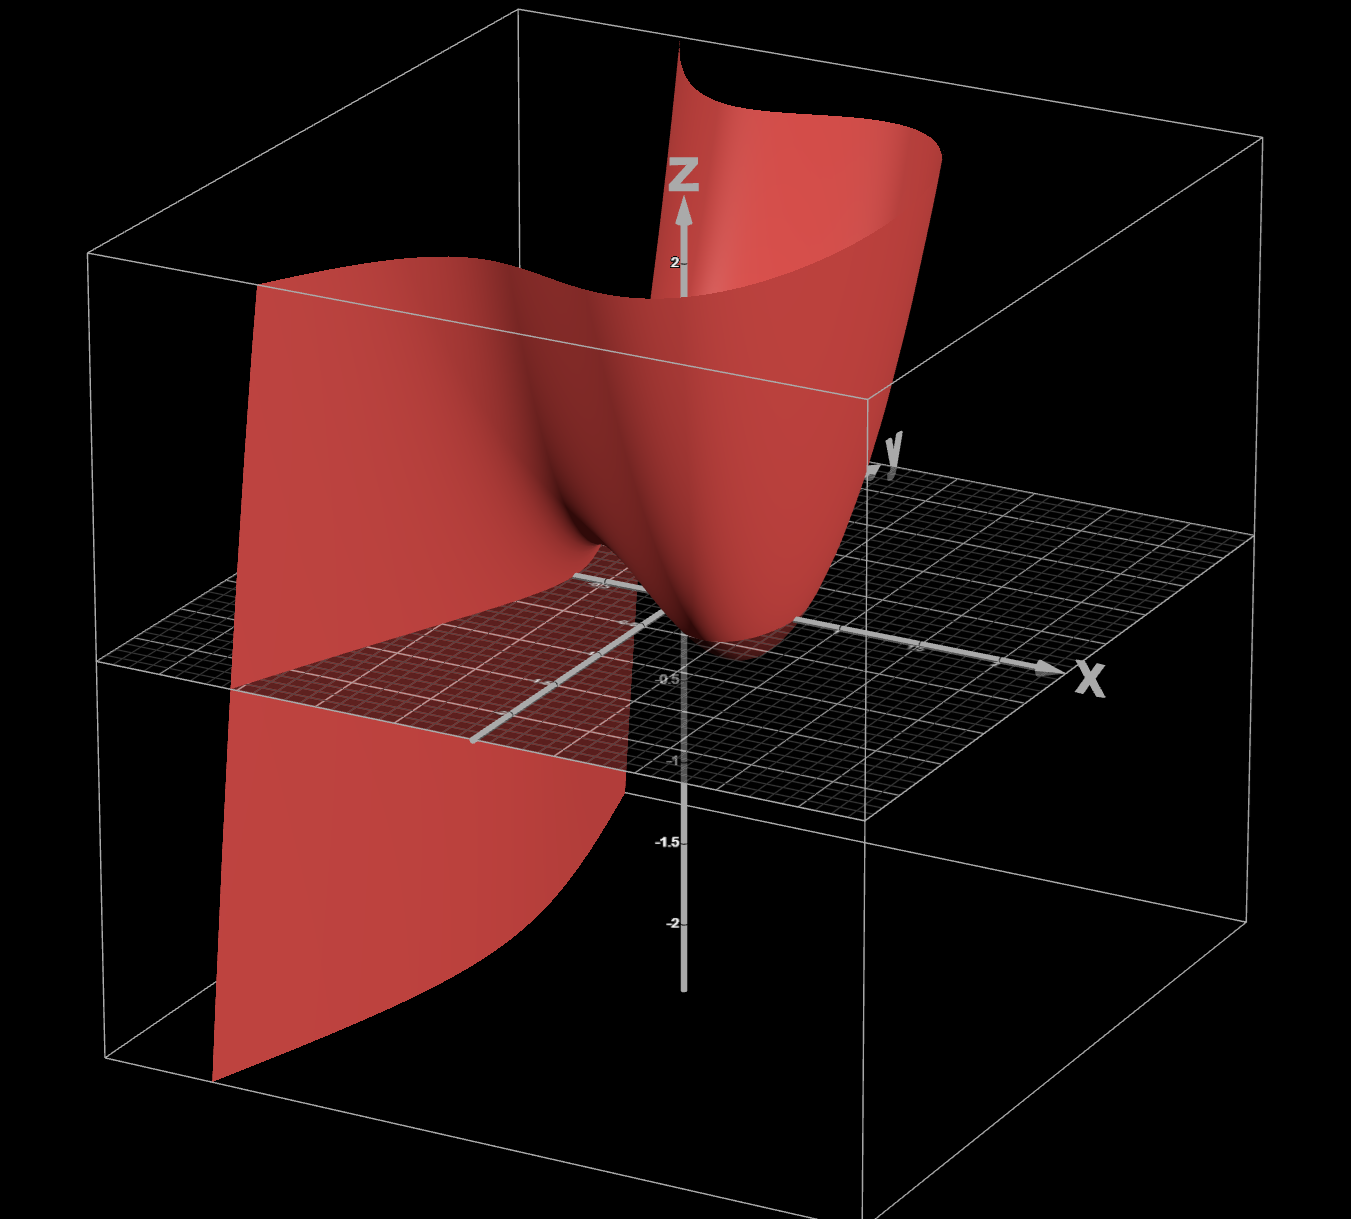

In [ ]:
from IPython.display import Image, display

display(Image(filename="Funcion_Concava_1.png", width=500, height=500))

Como vemos, para un punto inicial con $x > 0$ e $y > 0$, el algoritmo alcanzará el mínimo porque en esa región la función se comporta de manera convexa. Sin embargo, una elección del mínimo fuera de esa región va a hacer que el algoritmo diverja por entrar en la zona que no está acotada por abajo. Veamos una comparación con los siguientes gráficos:

In [ ]:
# Definición de la función
f = lambda x: 2*x[0]**3 + x[1]**2 - x[0]  # Función cúbica (no convexa)

# ==========================================
# Gradient Descent X0 adecuado
# ==========================================
x0 = jnp.array([2.0, 5.0])

_, _, cost_x0_adecuado = descenso_por_gradiente_basico(
    f,
    x0,
    learning_rate=0.05,
    iteraciones=50,
    verbose=False
)

# ==========================================
# Gradient Descent X0 NO adecuado
# ==========================================
x0 = jnp.array([-2.0, -5.0])

_, _, cost_x0_NO_adecuado = descenso_por_gradiente_basico(
    f,
    x0,
    learning_rate=0.05,
    iteraciones=50,
    verbose=False
)

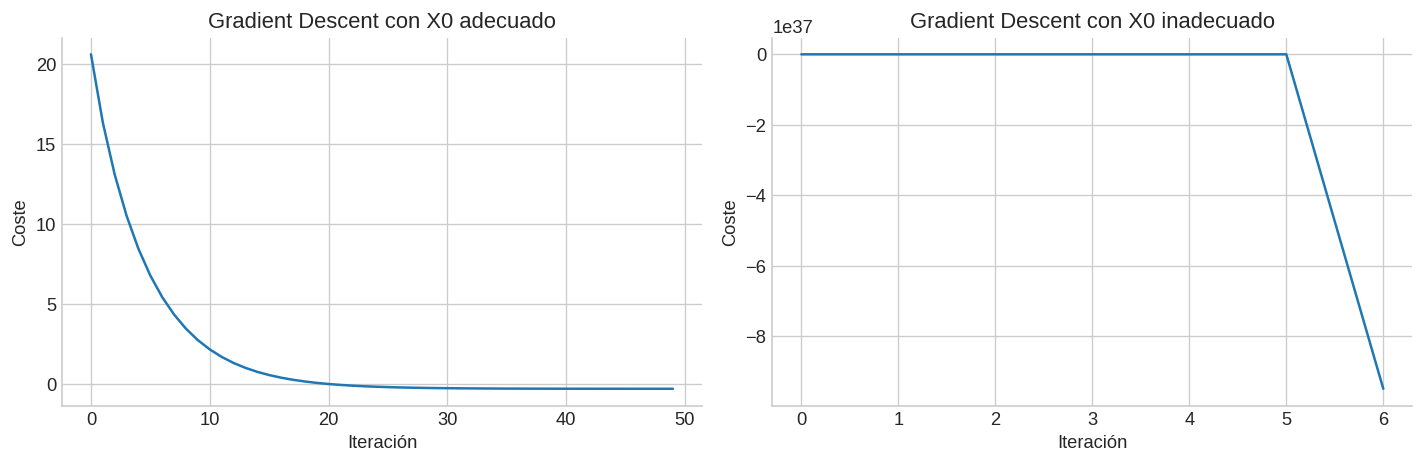

In [ ]:
# ==========================================
# Plot comparativo
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- X0 adecuado
axes[0].plot(cost_x0_adecuado)
axes[0].set_title("Gradient Descent con X0 adecuado")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Coste")
axes[0].grid(True)

# ---- X0 NO adecuado
axes[1].plot(cost_x0_NO_adecuado)
axes[1].set_title("Gradient Descent con X0 inadecuado")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Coste")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### e) Ineficiencia en regímenes de alta precisión

Cuando te acercas al óptimo, el descenso por gradiente entra en una fase donde el gradiente es muy pequeño. Esto implica:

- El algoritmo necesita muchas iteraciones para mejorar muy poco  
- La convergencia pasa de ser razonable a extremadamente lenta (*lineal*)  
- Ajustar el *learning rate* no soluciona el problema sin arriesgar estabilidad  

En esta fase suelen usarse métodos de segundo orden (como Newton) o *quasi-Newton* (BFGS), que aceleran significativamente la convergencia. El método de Newton es el que veremos en el siguiente apartado.

### 2.2 El método de Newton

<!-- Cap.3, seccion 3.3 Newtons Method paginas 51-53 -->

Ahora veremos como el método de Newton mejora sustancialmente la eficiencia de gradient descent, ya que en lugar de seguir únicamente la dirección de máximo descenso, Newton calcula una dirección que tiene en cuenta cómo cambia el gradiente en el espacio.

La dirección de búsqueda de Newton es (Nocedal & Wright, 2006, ec. 3.34):

$$p_k^N = -\nabla^2 f(x_k)^{-1} \nabla f(x_k)$$

donde $\nabla^2 f(x_k)$ es el Hessiano (la matriz de segundas derivadas
de $f$ evaluada en $x_k$). De manera que la iteración completa queda:

$$x_{k+1} = x_k + \alpha_k p_k^N$$

i.e., mientras GD asume que la función es localmente plana (aproximación de primer orden), Newton asume que es localmente cuadrática (aproximación de segundo orden).

La ventaja principal de Newton es su velocidad de convergencia. El Teorema 3.7 de Nocedal & Wright (2006) establece que, bajo condiciones de regularidad apropiadas:

1. Si el punto inicial $x_0$ es suficientemente cercano a la solución $x^*$,
   la secuencia de iterados converge a $x^*$
2. La tasa de convergencia es cuadrática
3. La secuencia de normas del gradiente $\{\|\nabla f_k\|\}$ converge
   cuadráticamente a cero

La convergencia cuadrática significa que el número de dígitos correctos
se duplica en cada iteración, lo cual es una gran mejora sobre la convergencia lineal de gradient descent.

A pesar de su convergencia superior, Newton presenta una limitación fundamental en la práctica. Cada iteración requiere:

1. Calcular $\nabla^2 f(x_k)$: una matriz de $n \times n$ segundas derivadas
   (coste $\mathcal{O}(n^2)$ en memoria y $\mathcal{O}(n^2)$ evaluaciones)
2. Factorizar (o invertir) $\nabla^2 f(x_k)$: coste $\mathcal{O}(n^3)$
   mediante eliminación gaussiana

Para problemas de alta dimensión (como calibrar un modelo con decenas de
parámetros, o un portafolio con cientos de activos) este coste es prohibitivo.
Además, el Hessiano puede no ser positivo definido fuera de la vecindad de $x^*$, lo que significa que $p_k^N$ podría no ser una dirección de descenso válida (Nocedal & Wright, 2006, p. 48).

| Método | Convergencia | Coste por iteración | Requiere Hessiano |
|--------|-------------|--------------------|--------------------|
| Gradient Descent | Lineal | $\mathcal{O}(n)$ | No |
| Newton | Cuadrática | $\mathcal{O}(n^3)$ | Sí |

Esta tensión entre velocidad de convergencia y coste computacional motiva
directamente el desarrollo de los métodos quasi-Newton.

In [ ]:
def optimizador_newton(f, x0, iteraciones=100):

    grad_f = grad(f)
    hessian_f = hessian(f)

    x = x0
    history_x = []
    history_cost = []

    history_x.append(x)
    history_cost.append(f(x))

    for i in range(iteraciones):
        g = grad_f(x)
        H = hessian_f(x)
        p = jnp.linalg.solve(H, g)   #MIRAR EN LA TEORÍA EL PASO CORRECTO

        x = x - p

        history_x.append(x)
        history_cost.append(f(x))

    return x, jnp.array(history_x), jnp.array(history_cost)

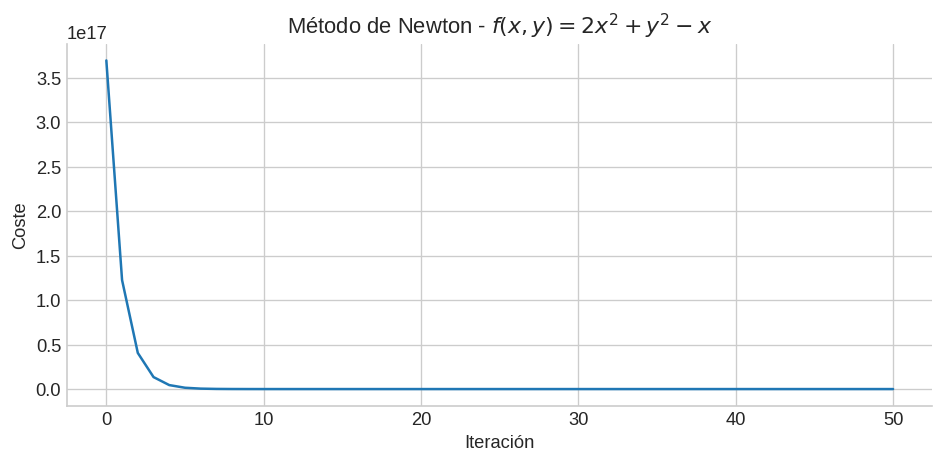

In [ ]:
f = lambda x: 2*x[0]**16 + x[1]**2 - x[0]
x0 = jnp.array([12.0, 3.0])

_, _, coste_Newton = optimizador_newton(
    f,
    x0,
    iteraciones=50)

# ---- Newton Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(coste_Newton)

ax.set_title(r"Método de Newton - $f(x,y)=2x^2 + y^2 - x$")
ax.set_xlabel("Iteración")
ax.set_ylabel("Coste")
ax.grid(True)

plt.tight_layout()
plt.show()

Como resumen, y respondiendo a las preguntas que propone el ejercicio tenemos lo siguiente. que el  método de descenso por gradiente utiliza únicamente información de primer orden:

$x_{k+1} = x_k - \alpha_k \nabla f(x_k)$

**Limitaciones:**

- No tiene en cuenta la curvatura de la función (no usa el Hessiano)
- Puede seguir direcciones de descenso subóptimas
- Convergencia lenta (lineal)
- Alta sensibilidad a la elección del learning rate

Como vimos, en funciones mal condicionadas (por ejemplo, valles), el algoritmo tiende a hacer zig-zag y tarda muchas iteraciones en converger.

---

El método de Newton utiliza información de segundo orden:

$x_{k+1} = x_k - H^{-1}(x_k)\nabla f(x_k)$

donde \(H(x_k)\) es el Hessiano de la función.

**Ventajas:**

- Tiene en cuenta la curvatura de la función
- Proporciona direcciones de descenso óptimas (localmente)
- Convergencia cuadrática cerca del óptimo

**Problemas:**

- Coste computacional elevado:
  - Cálculo del Hessiano: \(O(n^2)\)
  - Inversión del Hessiano: \(O(n^3)\)
- Puede no ser definido positivo → no garantiza dirección de descenso
- Puede ser inestable si el punto inicial está lejos del óptimo

Es por esto, que en los siguientes apartados vamos a desgranar los siguientes
métodos, que buscan mitigar estos problemas.

### 2.3 La idea quasi-Newton

<!-- Cap.3, quasi-Newton Method 49-50 -->
<!-- Cap.6, intro -->

En esta sección veremos como los métodos quasi-Newton surgen de la idea de conservar la rapidez de convergencia de los métodos de segundo orden, pero evitando el costo de calcular y factorizar el Hessiano en cada iteración.

En lugar de calcular $\nabla^2 f(x_k)$ exactamente, los métodos quasi-Newton
mantienen una matriz simétrica y positiva definida $B_k$ que aproxima el Hessiano, y definen la dirección de búsqueda como (Nocedal & Wright, 2006, ec. 3.30):

$$p_k = -B_k^{-1} \nabla f_k$$

Esta dirección tiene la misma forma que la dirección de Newton, pero usando
$B_k$ en lugar del Hessiano exacto $\nabla^2 f(x_k)$.
De hecho, no es necesario que $B_k$ converja al Hessiano exacto para obtener convergencia superlineal.

El Teorema 3.5 de Nocedal & Wright (2006) establece que basta con que las
matrices $B_k$ sean aproximaciones cada vez más precisas del Hessiano a lo
largo de las direcciones de búsqueda $p_k$, es decir:

$$\lim_{k \to \infty} \frac{\|(B_k - \nabla^2 f(x^*))p_k\|}{\|p_k\|} = 0$$

Como señalan Nocedal & Wright (2006, p. 50): la convergencia superlineal se puede lograr incluso si $B_k$ nunca converge al Hessiano exacto $\nabla^2 f(x^*)$.

En la práctica, esto supone una gran ventaja, ya que en lugar de calcular las $n^2$ segundas derivadas del Hessiano en cada iteración, los métodos quasi-Newton actualizan $B_k$ con una fórmula de rango bajo (usando solo los gradientes $\nabla f_k$ que ya calculamos). El coste por iteración se reduce de $\mathcal{O}(n^3)$ a
$\mathcal{O}(n^2)$.

| Método | Convergencia | Coste por iteración | Usa Hessiano exacto |
|--------|-------------|---------------------|---------------------|
| Gradient Descent | Lineal | $\mathcal{O}(n)$ | No |
| Newton | Cuadrática | $\mathcal{O}(n^3)$ | Sí |
| Quasi-Newton (BFGS) | Superlineal | $\mathcal{O}(n^2)$ | No |

Naturalmente, queda por precisar cómo se actualiza $B_k$ en cada iteración. Esa actualización viene dada por la fórmula BFGS, que desarrollaremos en la siguiente sección.

Hessiano exacto Q =
[[ 2.  0.]
 [ 0. 10.]]

Inverso exacto H* = Q⁻¹ =
[[0.5 0. ]
 [0.  0.1]]

 Iter |   ||H_k - H*||_F | H_k
────────────────────────────────────────────────────────────
    0 |         1.029563 | [1. 0.]
      |                  | [0. 1.]

    1 |         0.549853 | [ 1.0483 -0.0292]
      |                  | [-0.0292  0.1016]

    2 |         0.005615 | [0.5019 0.0027]
      |                  | [0.0027 0.1037]

    3 |         0.000089 | [ 0.5001 -0.    ]
      |                  | [-0.   0.1]

    4 |         0.000092 | [ 0.5001 -0.    ]
      |                  | [-0.   0.1]

    5 |         0.000092 | [ 0.5001 -0.    ]
      |                  | [-0.   0.1]



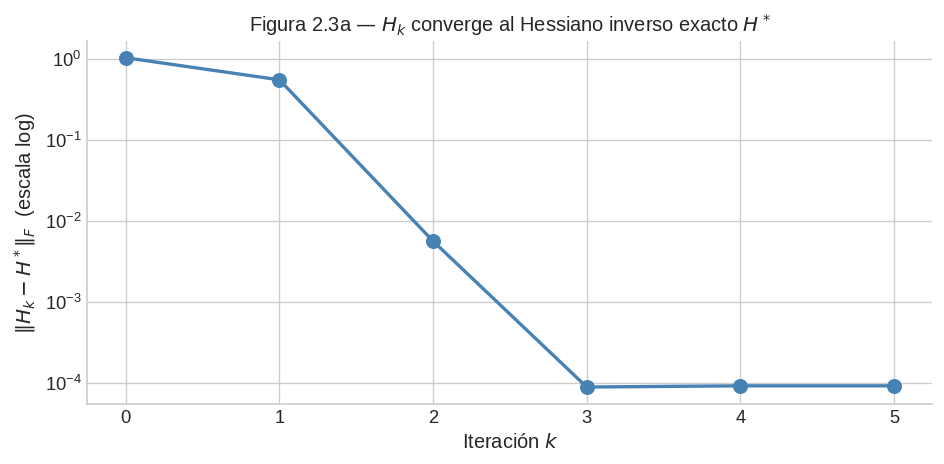

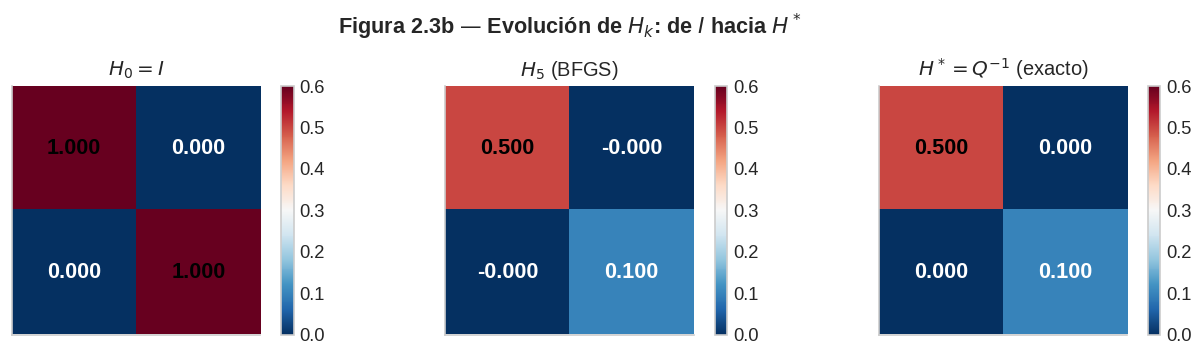

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función simple con Hessiano conocido
# f(x) = x1² + 5x2²
# Hessiano exacto: Q = [[2, 0], [0, 10]]
# Inverso exacto:  H* = [[1/2, 0], [0, 1/10]]

def f_simple(x):
    return x[0]**2 + 5*x[1]**2

def grad_simple(x):
    return np.array([2*x[0], 10*x[1]])

Q        = np.array([[2., 0.], [0., 10.]])
H_exacto = np.linalg.inv(Q)

print(f"Hessiano exacto Q =\n{Q}\n")
print(f"Inverso exacto H* = Q⁻¹ =\n{H_exacto}\n")

# Simulamos iteraciones BFGS observando cómo H_k -> H*
x  = np.array([2.0, 1.5])
H  = np.eye(2)   # H_0 = Identidad
c1 = 1e-4

errores_H    = [np.linalg.norm(H - H_exacto, 'fro')]
iteraciones_H = [0]
H_historia   = [H.copy()]

print(f"{'Iter':>5} | {'||H_k - H*||_F':>16} | H_k")
print("─" * 60)
print(f"{'0':>5} | {errores_H[0]:>16.6f} | {H[0]}")
print(f"{'':>5} | {'':>16} | {H[1]}\n")

for k in range(1, 6):
    g = grad_simple(x)
    p = -H @ g

    # Backtracking Armijo
    alpha = 1.0
    while f_simple(x + alpha * p) > f_simple(x) + c1 * alpha * (g @ p):
        alpha *= 0.5

    x_new = x + alpha * p
    s     = x_new - x
    y     = grad_simple(x_new) - g
    sy    = s @ y

    if sy > 1e-10:
        rho_k = 1.0 / sy
        I     = np.eye(2)
        V     = I - rho_k * np.outer(s, y)
        H     = V @ H @ V.T + rho_k * np.outer(s, s)

    x     = x_new
    error = np.linalg.norm(H - H_exacto, 'fro')
    errores_H.append(error)
    iteraciones_H.append(k)
    H_historia.append(H.copy())

    print(f"{k:>5} | {error:>16.6f} | {H[0].round(4)}")
    print(f"{'':>5} | {'':>16} | {H[1].round(4)}\n")

# Figura 1: error de aproximación
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(iteraciones_H, errores_H,
            'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Iteración $k$', fontsize=12)
ax.set_ylabel(r'$\|H_k - H^*\|_F$  (escala log)', fontsize=12)
ax.set_title('Figura 2.3a — $H_k$ converge al Hessiano inverso exacto $H^*$',
             fontsize=12)
plt.tight_layout()
plt.show()

# Figura 2: heatmaps H_0 -> H_k -> H*
fig2, axes2 = plt.subplots(1, 3, figsize=(11, 3))
titulos  = ['$H_0 = I$', f'$H_{k}$ (BFGS)', '$H^* = Q^{-1}$ (exacto)']
matrices = [np.eye(2), H_historia[-1], H_exacto]

for ax, mat, tit in zip(axes2, matrices, titulos):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=0, vmax=0.6)
    ax.set_title(tit, fontsize=12)
    # Anotar valores en cada celda
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{mat[i,j]:.3f}',
                    ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if mat[i,j] < 0.2 else 'black')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax)

fig2.suptitle('Figura 2.3b — Evolución de $H_k$: de $I$ hacia $H^*$',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Derivación de BFGS

<!-- Cap.8, 8.1 implementación -->

Comencemos notando que en cada iteración $k$, BFGS aproxima la función objetivo mediante un modelo cuadrático local (Nocedal & Wright, 2006, ec. 8.1):

$$m_k(p) = f_k + \nabla f_k^T p + \frac{1}{2} p^T B_k p$$

donde $B_k$ es una matriz simétrica y positiva definida que aproxima el Hessiano $\nabla^2 f(x_k)$. El minimizador de este modelo define la dirección de búsqueda:

$$p_k = -B_k^{-1} \nabla f_k$$

y el nuevo iterado es $x_{k+1} = x_k + \alpha_k p_k$, donde $\alpha_k$ satisface las condiciones de Wolfe.

Ahora, la idea central es imponer que el nuevo modelo $m_{k+1}$ interpole el gradiente de $f$ en los dos últimos iterados $x_k$ y $x_{k+1}$. Esto conduce a la ecuación secante (Nocedal & Wright, 2006, ec. 8.6):

$$B_{k+1} s_k = y_k$$

donde definimos los vectores de desplazamiento y cambio de gradiente:

$$s_k = x_{k+1} - x_k, \qquad y_k = \nabla f_{k+1} - \nabla f_k$$

La ecuación secante exige que $B_{k+1}$ mapee el desplazamiento $s_k$ al cambio de gradiente $y_k$ (una condición natural que captura la curvatura observada durante el paso).

Luego, para que $B_{k+1}$ sea positiva definida (garantizando que $p_{k+1}$ sea una dirección de descenso válida), es necesario que se satisfaga la
condición de curvatura (Nocedal & Wright, 2006, ec. 8.7):

$$s_k^T y_k > 0$$

Esta condición se garantiza automáticamente si el paso $\alpha_k$ se elige
satisfaciendo las condiciones de Wolfe. Para funciones fuertemente convexas
se cumple siempre pero en casos generales debe imponerse explícitamente.

Por otro lado, notemos que la ecuación secante tiene infinitas soluciones (ya que hay $n(n+1)/2$ grados de libertad en una matriz simétrica pero solo $n$ condiciones). Para determinar $B_{k+1}$ unívocamente, BFGS impone que sea la matriz más cercana a $B_k$ que satisfaga la ecuación secante, en la norma de Frobenius ponderada.

En la práctica, es más conveniente trabajar con la inversa del Hessiano
aproximado $H_k = B_k^{-1}$, cuya actualización es (Nocedal & Wright, 2006,
ec. 8.16):

$$H_{k+1} = \left(I - \rho_k s_k y_k^T\right) H_k
\left(I - \rho_k y_k s_k^T\right) + \rho_k s_k s_k^T$$

donde:

$$\rho_k = \frac{1}{y_k^T s_k}$$

Esta es la fórmula BFGS. Notemos que $H_{k+1}$ se obtiene de $H_k$ mediante una modificación de rango 2, usando solo los vectores $s_k$ e $y_k$. No se requiere ninguna segunda derivada.

De esta manera, reuniendo todo lo comentado, el Algoritmo 8.1 de Nocedal & Wright (2006) es:

Dado $x_0$, tolerancia $\epsilon > 0$, aproximación inicial $H_0$
(típicamente $H_0 = I$)

**while** $\|\nabla f_k\| > \epsilon$:
1. Calcular dirección de búsqueda: $p_k = -H_k \nabla f_k$
2. Determinar paso $\alpha_k$ satisfaciendo las condiciones de Wolfe
3. Actualizar: $x_{k+1} = x_k + \alpha_k p_k$
4. Calcular: $s_k = x_{k+1} - x_k$, $\quad y_k = \nabla f_{k+1} - \nabla f_k$
5. Actualizar $H_{k+1}$ usando la fórmula (8.16)
6. $k \leftarrow k + 1$

**end**

Cada iteración tiene un coste de $\mathcal{O}(n^2)$ operaciones — sin sistemas lineales, sin segundas derivadas.

Por último, vale la pena mencionar que una propiedad práctica importante de BFGS es su capacidad de autocorrección, i.e., si en alguna iteración $H_k$ es una mala aproximación del Hessiano inverso, el algoritmo tiende a corregirse en las iteraciones siguientes, siempre que la búsqueda de línea sea adecuada (Nocedal & Wright, 2006, p. 201). Esto contrasta con el método DFP que tiene propiedades de autocorrección significativamente más débiles.

In [ ]:
import numpy as np

# Función simple f(x) = x1² + 5x2²
def f(x):      return x[0]**2 + 5*x[1]**2
def grad_f(x): return np.array([2*x[0], 10*x[1]])

print("=" * 60)
print("   Derivación numérica de BFGS ")
print("=" * 60)

# Iteración 0
x0 = np.array([2.0, 1.5])
H0 = np.eye(2)
g0 = grad_f(x0)

print(f"\n Punto inicial:     x_0 = {x0}")
print(f"   Gradiente:        ∇f(x_0) = {g0}")
print(f"   H_0 (identidad):\n{H0}\n")

# Paso 1: dirección de búsqueda
p0 = -H0 @ g0
print(f"** Paso 1: Dirección de búsqueda ***********")
print(f"   p_0 = -H_0 · ∇f(x_0) = -{H0[0]} · {g0}")
print(f"   p_0 = {p0}\n")

# Paso 2: búsqueda de línea
alpha = 1.0
c1    = 1e-4
while f(x0 + alpha * p0) > f(x0) + c1 * alpha * (g0 @ p0):
    alpha *= 0.5

x1 = x0 + alpha * p0
print(f"** Paso 2: Búsqueda de línea (Armijo) ***********")
print(f"   α_0 = {alpha:.6f}")
print(f"   x_1 = x_0 + α_0·p_0 = {x1}\n")

# Paso 3: calcular s_k e y_k
g1 = grad_f(x1)
s0 = x1 - x0
y0 = g1 - g0
print(f"** Paso 3: Vectores s_0 e y_0 ***********")
print(f"   s_0 = x_1 - x_0 = {s0}")
print(f"   y_0 = ∇f(x_1) - ∇f(x_0) = {g1} - {g0} = {y0}")
print(f"   s_0ᵀ y_0 = {s0 @ y0:.6f}  (debe ser > 0 )\n")

# Paso 4: actualizar H
rho0 = 1.0 / (s0 @ y0)
I    = np.eye(2)
V0   = I - rho0 * np.outer(s0, y0)
H1   = V0 @ H0 @ V0.T + rho0 * np.outer(s0, s0)

print(f"** Paso 4: Actualización BFGS (fórmula 8.16) ***********")
print(f"   ρ_0 = 1/(s_0ᵀy_0) = 1/{s0@y0:.4f} = {rho0:.6f}")
print(f"   H_1 = (I - ρ_0·s_0·y_0ᵀ)·H_0·(I - ρ_0·y_0·s_0ᵀ) + ρ_0·s_0·s_0ᵀ")
print(f"\n   H_1 =\n{H1.round(6)}")

# Comparación con H*
H_exacto = np.linalg.inv(np.array([[2., 0.], [0., 10.]]))
print(f"\n   H* = Q⁻¹ =\n{H_exacto}")
print(f"\n   ||H_1 - H*||_F = {np.linalg.norm(H1 - H_exacto, 'fro'):.6f}")
print(f"   ||H_0 - H*||_F = {np.linalg.norm(H0 - H_exacto, 'fro'):.6f}")
print(f"\n H_1 es {np.linalg.norm(H0-H_exacto,'fro')/np.linalg.norm(H1-H_exacto,'fro'):.1f}x más cercano a H* que H_0")

   Derivación numérica de BFGS 

 Punto inicial:     x_0 = [2.  1.5]
   Gradiente:        ∇f(x_0) = [ 4. 15.]
   H_0 (identidad):
[[1. 0.]
 [0. 1.]]

** Paso 1: Dirección de búsqueda ***********
   p_0 = -H_0 · ∇f(x_0) = -[1. 0.] · [ 4. 15.]
   p_0 = [ -4. -15.]

** Paso 2: Búsqueda de línea (Armijo) ***********
   α_0 = 0.125000
   x_1 = x_0 + α_0·p_0 = [ 1.5   -0.375]

** Paso 3: Vectores s_0 e y_0 ***********
   s_0 = x_1 - x_0 = [-0.5   -1.875]
   y_0 = ∇f(x_1) - ∇f(x_0) = [ 3.   -3.75] - [ 4. 15.] = [ -1.   -18.75]
   s_0ᵀ y_0 = 35.656250  (debe ser > 0 )

** Paso 4: Actualización BFGS (fórmula 8.16) ***********
   ρ_0 = 1/(s_0ᵀy_0) = 1/35.6562 = 0.028046
   H_1 = (I - ρ_0·s_0·y_0ᵀ)·H_0·(I - ρ_0·y_0·s_0ᵀ) + ρ_0·s_0·s_0ᵀ

   H_1 =
[[ 1.048293 -0.029242]
 [-0.029242  0.10156 ]]

   H* = Q⁻¹ =
[[0.5 0. ]
 [0.  0.1]]

   ||H_1 - H*||_F = 0.549853
   ||H_0 - H*||_F = 1.029563

 H_1 es 1.9x más cercano a H* que H_0


**Observación 2.4:** Tras una sola iteración, $H_1$ ya es 1.9 veces
más cercano a $H^*$ que $H_0$. Nótese además que $H_1$ no es diagonal
(aparecen términos fuera de la diagonal ($-0.029$)) aunque $Q$ sí lo es.
Esto refleja que BFGS construye la aproximación usando información
direccional, no estructura analítica de $f$.

### 2.5 Propiedades teóricas de BFGS

<!-- Cap.8, +Superlinear Convergence of BFGS -->

#### 1. Preservación de la positividad definida

Una propiedad fundamental de BFGS es que si $H_k$ es positiva definida y se
satisface la condición de curvatura $s_k^T y_k > 0$, entonces $H_{k+1}$ también es positiva definida. Esto se verifica directamente: para cualquier vector $z \neq 0$ (Nocedal & Wright, 2006, p. 199):

$$z^T H_{k+1} z = w^T H_k w + \rho_k (z^T s_k)^2 \geq 0$$

donde $w = z - \rho_k y_k (s_k^T z)$. El lado derecho solo puede ser cero si
$s_k^T z = 0$ y $w = 0$, lo que implicaría $z = 0$ (i.e. una contradicción). Por tanto, $H_{k+1}$ es positiva definida, garantizando que $p_k = -H_k \nabla f_k$ sea siempre una dirección de descenso válida.

#### 2. Convergencia global

El siguiente resultado establece la convergencia global de BFGS bajo condiciones
generales (Nocedal & Wright, 2006, Sec. 8.4):

Teorema (Convergencia global de BFGS).Si $f$ es fuertemente convexa y
sus segundas derivadas son Lipschitz continuas, entonces el método BFGS con
condiciones de Wolfe converge a la solución global $x^*$ desde cualquier punto inicial $x_0$.

La demostración usa el Teorema de Zoutendijk para mostrar que
$\sum_k \cos^2\theta_k \|\nabla f_k\|^2 < \infty$, donde $\theta_k$ es el
ángulo entre $p_k$ y $-\nabla f_k$. La positividad definida de $H_k$ garantiza
que este ángulo nunca se aproxime a 90°, asegurando progreso en cada iteración.

#### 3. Convergencia superlineal

La propiedad más destacable de BFGS es su tasa de convergencia. El Teorema 8.6 de Nocedal & Wright (2006) establece:

Teorema 8.6. Suponga que $f$ es dos veces continuamente diferenciable y
que los iterados generados por BFGS convergen a un minimizador $x^*$ donde el Hessiano $\nabla^2 f(x^*)$ es positiva definida y Lipschitz continuo. Entonces $x_k \to x^*$ a una tasa superlineal.

La prueba usa la caracterización de Dennis–Moré (ec. 3.32): la convergencia
es superlineal si y solo si las matrices $B_k$ se convierten en aproximaciones cada vez más precisas del Hessiano a lo largo de las direcciones de búsqueda, es decir:

$$\lim_{k\to\infty} \frac{\|(B_k - \nabla^2 f(x^*))s_k\|}{\|s_k\|} = 0$$

BFGS satisface esta condición automáticamente gracias a su fórmula de
actualización, sin que $B_k$ converja al Hessiano exacto.

#### 4. Comparación empírica

Nocedal & Wright (2006, p. 199) reportan el siguiente experimento en la función de Rosenbrock desde el punto $(-1.2, 1)$:

| Método | Iteraciones hasta $\|\nabla f\| < 10^{-5}$ |
|--------|---------------------------------------------|
| Steepest Descent | 5264 |
| BFGS | 34 |
| Newton | 21 |

BFGS requiere 155 veces menos iteraciones que gradient descent, y solo
1.6 veces más que Newton (pero sin calcular ninguna segunda derivada).
Este es el balance que lo convierte en el estándar.

En resumen tenemos:

| Propiedad | BFGS |
|-----------|------|
| Preserva positividad definida | Siempre (si $s_k^T y_k > 0$) |
| Convergencia global | Para $f$ fuertemente convexa |
| Tasa de convergencia | Superlineal |
| Requiere segundas derivadas | No |
| Coste por iteración | $\mathcal{O}(n^2)$ |
| Autocorrección | Propiedad característica |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

def gradient_descent_armijo(
    f: Callable,
    grad_f: Callable,
    x0: np.ndarray,
    max_iter: int = 10000,
    tol: float = 1e-6,
    alpha_init: float = 1.0,
    rho: float = 0.5,
    c: float = 1e-4
) -> dict:
    """
    Gradient Descent con backtracking de Armijo.

    Parámetros:
    -----------
    f        : función objetivo
    grad_f   : gradiente de f
    x0       : punto inicial
    max_iter : máximo de iteraciones
    tol      : tolerancia para ||∇f||
    alpha_init: paso inicial (aquí Nocedal nos recomienda 1.0)
    rho      : factor de contracción ∈ (0,1)
    c        : constante Armijo ∈ (0,1)

    Retorna:
    --------
    dict con: x_opt, f_opt, iteraciones, historial de f, trayectoria
    """
    x = x0.copy().astype(float)
    historial_f = [f(x)]
    trayectoria = [x.copy()]

    for k in range(max_iter):
        g = grad_f(x)

        # Criterio de parada
        if np.linalg.norm(g) < tol:
            break

        p = -g  # dirección de descenso

        # Backtracking Armijo
        alpha = alpha_init
        f_actual = f(x)
        while f(x + alpha * p) > f_actual + c * alpha * np.dot(g, p):
            alpha *= rho
        #

        x = x + alpha * p
        historial_f.append(f(x))
        trayectoria.append(x.copy())

    return {
        'x_opt'      : x,
        'f_opt'      : f(x),
        'iteraciones': k + 1,
        'historial_f': np.array(historial_f),
        'trayectoria': np.array(trayectoria)
    }

In [ ]:
from typing import Callable, Tuple

def bfgs(
    f: Callable,
    grad_f: Callable,
    x0: np.ndarray,
    max_iter: int = 1000,
    tol: float = 1e-6,
    c1: float = 1e-4,
    c2: float = 0.9
) -> dict:
    """
    BFGS con búsqueda de línea de Wolfe.
    Implementación del Algoritmo 8.1 de Nocedal & Wright (2006).

    Parámetros:
    -----------
    f      : función objetivo
    grad_f : gradiente de f
    x0     : punto inicial
    max_iter: máximo de iteraciones
    tol    : tolerancia para ||∇f||
    c1, c2 : constantes de Wolfe (c1=Armijo, c2=curvatura)
    """
    n = len(x0)
    x = x0.copy().astype(float)
    H = np.eye(n)  # H_0 = I (identidad)

    historial_f  = [f(x)]
    trayectoria  = [x.copy()]

    def wolfe_search(x, p, g, f_x, alpha_max=1.0):
        """Búsqueda de línea con condiciones de Wolfe."""
        alpha = alpha_max
        rho   = 0.5
        for _ in range(100):
            x_new = x + alpha * p
            # Condición de Armijo (sufficient decrease)
            if f(x_new) > f_x + c1 * alpha * np.dot(g, p):
                alpha *= rho
                continue
            # Condición de curvatura (Wolfe)
            if np.dot(grad_f(x_new), p) < c2 * np.dot(g, p):
                alpha *= rho
                continue
            break
        return alpha

    for k in range(max_iter):
        g = grad_f(x)

        # Criterio de parada
        if np.linalg.norm(g) < tol:
            break

        # 1. Dirección de búsqueda
        p = -H @ g

        # 2. Búsqueda de línea (Wolfe)
        alpha = wolfe_search(x, p, g, f(x))

        # 3. Actualizar x
        x_new = x + alpha * p

        # 4. Calcular s_k e y_k
        s = x_new - x                    # s_k = x_{k+1} - x_k
        y = grad_f(x_new) - g           # y_k = ∇f_{k+1} - ∇f_k

        # 5. Actualizar H (fórmula 8.16)
        sy = np.dot(s, y)
        if sy > 1e-10:  # condición de curvatura s_k^T y_k > 0
            rho_k = 1.0 / sy
            I     = np.eye(n)
            V     = I - rho_k * np.outer(s, y)
            H     = V @ H @ V.T + rho_k * np.outer(s, s)

        x = x_new
        historial_f.append(f(x))
        trayectoria.append(x.copy())

    return {
        'x_opt'      : x,
        'f_opt'      : f(x),
        'iteraciones': k + 1,
        'historial_f': np.array(historial_f),
        'trayectoria': np.array(trayectoria)
    }

  Propiedad 1 — Positividad definida de H_k

 Iter |       eigenvalores de H_k |  H_k positiva def?
───────────────────────────────────────────────────────
    0 |                   [1. 1.] |                 Sí
    1 |   [8.0000e-04 1.0004e+00] |                 Sí
    2 |           [0.0004 0.2172] |                 Sí
    3 |           [0.0018 0.2614] |                 Sí
    4 |           [0.0024 0.112 ] |                 Sí
    5 |           [0.0024 0.0796] |                 Sí

  Propiedad 2 — Tasa de convergencia superlineal

 Iter |    ||x_k - x*|| |      ratio
──────────────────────────────────────
    0 |        2.20e+00 |          —
    1 |        1.99e+00 |          —
    2 |        1.82e+00 |     0.9158
    3 |        1.81e+00 |     0.9907
    4 |        1.70e+00 |     0.9389
    5 |        1.67e+00 |     0.9829
    6 |        1.63e+00 |     0.9782
    7 |        1.61e+00 |     0.9866
    8 |        1.59e+00 |     0.9867
    9 |        1.50e+00 |     0.9467

  Propiedad 3 — 

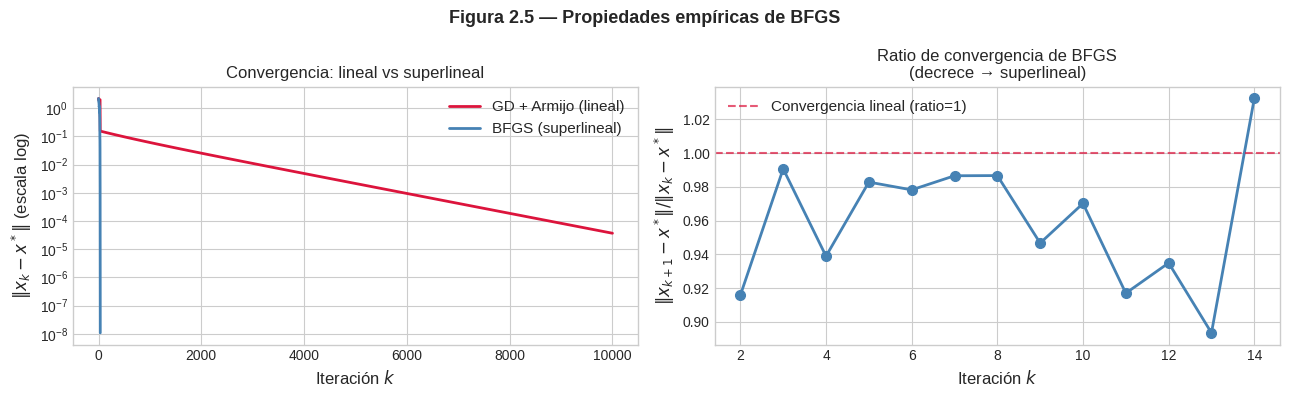

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ** Función de Rosenbrock *****************************************************
def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    dx0 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dx1 = 200*(x[1] - x[0]**2)
    return np.array([dx0, dx1])

x0 = np.array([-1.2, 1.0])

# ** 1. Propiedad: Positividad definida ****************************************
print("=" * 55)
print("  Propiedad 1 — Positividad definida de H_k")
print("=" * 55)

x  = x0.copy()
H  = np.eye(2)
c1 = 1e-4

print(f"\n{'Iter':>5} | {'eigenvalores de H_k':>25} | {'H_k positiva def?':>18}")
print("─" * 55)

for k in range(6):
    eigenvalores = np.linalg.eigvalsh(H)
    es_pos_def   = np.all(eigenvalores > 0)
    print(f"{k:>5} | {str(eigenvalores.round(4)):>25} | {'Sí' if es_pos_def else 'No':>18}")

    g = grad_rosenbrock(x)
    if np.linalg.norm(g) < 1e-6:
        break
    p = -H @ g

    alpha = 1.0
    while rosenbrock(x + alpha*p) > rosenbrock(x) + c1*alpha*(g@p):
        alpha *= 0.5

    x_new = x + alpha*p
    s = x_new - x
    y = grad_rosenbrock(x_new) - g
    sy = s @ y

    if sy > 1e-10:
        rho_k = 1.0 / sy
        I     = np.eye(2)
        V     = I - rho_k * np.outer(s, y)
        H     = V @ H @ V.T + rho_k * np.outer(s, s)
    x = x_new

# ** 2. Propiedad: Convergencia superlineal ************************************
print("\n" + "=" * 55)
print("  Propiedad 2 — Tasa de convergencia superlineal")
print("=" * 55)

# Corremos BFGS completo guardando errores
resultado_bfgs  = bfgs(rosenbrock, grad_rosenbrock, x0)
resultado_gd    = gradient_descent_armijo(rosenbrock, grad_rosenbrock, x0)

tray_bfgs = resultado_bfgs['trayectoria']
x_star    = np.array([1.0, 1.0])
errores   = [np.linalg.norm(x - x_star) for x in tray_bfgs]

print(f"\n{'Iter':>5} | {'||x_k - x*||':>15} | {'ratio':>10}")
print("─" * 38)
for k in range(min(10, len(errores))):
    if k >= 2 and errores[k-1] > 1e-15:
        ratio = errores[k] / errores[k-1]
        print(f"{k:>5} | {errores[k]:>15.2e} | {ratio:>10.4f}")
    else:
        print(f"{k:>5} | {errores[k]:>15.2e} | {'—':>10}")

# ** 3. Propiedad: Tabla comparativa *******************************************
print("\n" + "=" * 55)
print("  Propiedad 3 — Comparación empírica en Rosenbrock")
print("=" * 55)
print(f"\n{'Método':<20} {'Iteraciones':>12} {'f(x_opt)':>14} {'||x-x*||':>12}")
print("─" * 60)
print(f"{'GD + Armijo':<20} {resultado_gd['iteraciones']:>12} "
      f"{resultado_gd['f_opt']:>14.2e} "
      f"{np.linalg.norm(resultado_gd['x_opt']-x_star):>12.2e}")
print(f"{'BFGS (propio)':<20} {resultado_bfgs['iteraciones']:>12} "
      f"{resultado_bfgs['f_opt']:>14.2e} "
      f"{np.linalg.norm(resultado_bfgs['x_opt']-x_star):>12.2e}")
print(f"{'Nocedal (ref.)':<20} {'34':>12} {'—':>14} {'—':>12}")

# ** Figura: convergencia superlineal vs lineal ********************************
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Errores GD
errores_gd = [np.linalg.norm(x - x_star)
              for x in resultado_gd['trayectoria']]

axes[0].semilogy(errores_gd,
                 color='crimson',   linewidth=2, label='GD + Armijo (lineal)')
axes[0].semilogy(errores,
                 color='steelblue', linewidth=2, label='BFGS (superlineal)')
axes[0].set_xlabel('Iteración $k$', fontsize=12)
axes[0].set_ylabel(r'$\|x_k - x^*\|$ (escala log)', fontsize=12)
axes[0].set_title('Convergencia: lineal vs superlineal', fontsize=12)
axes[0].legend(fontsize=11)

# Ratio de convergencia de BFGS
ratios = [errores[k]/errores[k-1]
          for k in range(2, min(15, len(errores)))
          if errores[k-1] > 1e-15]
axes[1].plot(range(2, 2+len(ratios)), ratios,
             'o-', color='steelblue', linewidth=2, markersize=7)
axes[1].axhline(y=1, color='crimson', linestyle='--',
                alpha=0.7, label='Convergencia lineal (ratio=1)')
axes[1].set_xlabel('Iteración $k$', fontsize=12)
axes[1].set_ylabel(r'$\|x_{k+1}-x^*\| / \|x_k-x^*\|$', fontsize=12)
axes[1].set_title('Ratio de convergencia de BFGS\n(decrece → superlineal)',
                  fontsize=12)
axes[1].legend(fontsize=11)

plt.suptitle('Figura 2.5 — Propiedades empíricas de BFGS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observación 2.5:**

1. Positividad definida: $H_k$ mantiene eigenvalores positivos en
   todas las iteraciones
2. Convergencia superlineal:el ratio $\|x_{k+1}-x^*\|/\|x_k-x^*\|$
   se mantiene por debajo de 1 y decrece (confirma superlinealidad )  
3. Comparación empírica: BFGS converge en 35 iteraciones vs 10,000
   de GD, resultado consistente con Nocedal & Wright (2006) que reportan 34

### 2.6 L-BFGS: BFGS con memoria limitada

<!-- Cap.9,  -->

BFGS estándar requiere almacenar y actualizar la matriz $H_k$ de tamaño
$n \times n$. Para problemas con miles o millones de variables esto se
vuelve prohibitivo tanto en memoria ($\mathcal{O}(n^2)$) como en cómputo.

L-BFGS (Limited-memory BFGS) resuelve exactamente este problema, ya que en lugar de almacenar $H_k$ explícitamente, guarda solo los $m$ pares de vectores más recientes $\{s_i, y_i\}$ y reconstruye el producto $H_k \nabla f_k$ implícitamente cuando se necesita (Nocedal & Wright, 2006, p. 224).

En cada iteración, L-BFGS mantiene un conjunto deslizante de $m$ pares
de corrección:

$$\{s_{k-m}, y_{k-m}\}, \{s_{k-m+1}, y_{k-m+1}\}, \ldots, \{s_{k-1}, y_{k-1}\}$$

donde $s_i = x_{i+1} - x_i$ y $y_i = \nabla f_{i+1} - \nabla f_i$. Al
calcular un nuevo iterado, el par más antiguo se descarta y se añade el nuevo.
La experiencia práctica muestra que valores modestos de $m$ (entre 3 y 20)
producen resultados satisfactorios (Nocedal & Wright, 2006, p. 225).

El producto $H_k \nabla f_k$ se calcula eficientemente mediante la recursión de dos bucles (Algoritmo 9.1, Nocedal & Wright, 2006):

1. Inicializar $q \leftarrow \nabla f_k$
2. Primer bucle(hacia atrás), $i = k-1, k-2, \ldots, k-m$:
   - $\alpha_i \leftarrow \rho_i s_i^T q$
   - $q \leftarrow q - \alpha_i y_i$
3. Aplicar aproximación inicial: $r \leftarrow H_k^0 q$
4. Segundo bucle (hacia adelante), $i = k-m, k-m+1, \ldots, k-1$:
   - $\beta \leftarrow \rho_i y_i^T r$
   - $r \leftarrow r + s_i(\alpha_i - \beta)$
5. Resultado: $H_k \nabla f_k = r$

Este procedimiento requiere solo $4mn$ multiplicaciones, i.e., coste
$\mathcal{O}(mn)$ en lugar de $\mathcal{O}(n^2)$ de BFGS estándar.

Notemos que una elección efectiva para la matriz inicial $H_k^0$ en cada iteración es (Nocedal & Wright, 2006, ec. 9.6):

$$H_k^0 = \gamma_k I \qquad \gamma_k = \frac{s_{k-1}^T y_{k-1}}{y_{k-1}^T y_{k-1}}$$

Este escalado estima el tamaño del Hessiano verdadero a lo largo de la
dirección de búsqueda más reciente, ayudando a que $\alpha_k = 1$ sea
aceptado en la mayoría de iteraciones.

La Tabla 9.1 de Nocedal & Wright (2006) reporta el comportamiento de
L-BFGS para distintos valores de $m$ en problemas de referencia:

| Problema | $n$ | $m=3$ | $m=5$ | $m=17$ | $m=29$ |
|----------|-----|-------|-------|--------|--------|
| DIXMAANL | 1500 | 146 iter | 134 iter | 120 iter | 125 iter |
| EIGENALS | 110 | 821 iter | 569 iter | 363 iter | 168 iter |
| FREUROTH | 1000 | >999 | >999 | 69 iter | 38 iter |
| TRIDIA | 1000 | 876 iter | 611 iter | 531 iter | 462 iter |

El número óptimo de $m$ es dependiente del problema (más memoria no
siempre es mejor) y el mejor tiempo de CPU frecuentemente se obtiene
con valores pequeños de $m$.

#### Resumen final BFGS vs L-BFGS

| Característica | BFGS | L-BFGS |
|----------------|------|--------|
| Memoria | $\mathcal{O}(n^2)$ | $\mathcal{O}(mn)$ |
| Coste por iteración | $\mathcal{O}(n^2)$ | $\mathcal{O}(mn)$ |
| Convergencia | Superlineal | Lineal (típicamente) |
| Problemas grandes | Impractical | Diseñado para esto |
| Parámetro extra | — | $m$ (historial) |
| En `scipy` | `method='BFGS'` | `method='L-BFGS-B'` |

Por último, vale la pena mencionar que las principales limitaciones de L-BFGS son (Nocedal & Wright, 2006, p. 227) que converge más lentamente que BFGS estándar en problemas pequeños, que es ineficiente en problemas mal condicionados donde el Hessiano tiene una distribución amplia de valores propios y que su rendimiento depende de la elección de $m$.



  m (historial) |  Iteraciones |       f(x_opt) |     ||x-x*||
──────────────────────────────────────────────────────────
              1 |           37 |       7.71e-07 |     1.96e-03
              3 |           37 |       6.13e-12 |     4.72e-06
              5 |           37 |       1.73e-09 |     6.29e-05
             10 |           35 |       5.30e-10 |     7.70e-06
             20 |           36 |       5.86e-10 |     6.62e-06
──────────────────────────────────────────────────────────
BFGS (completo) |           35 |       2.75e-17 |     1.09e-08


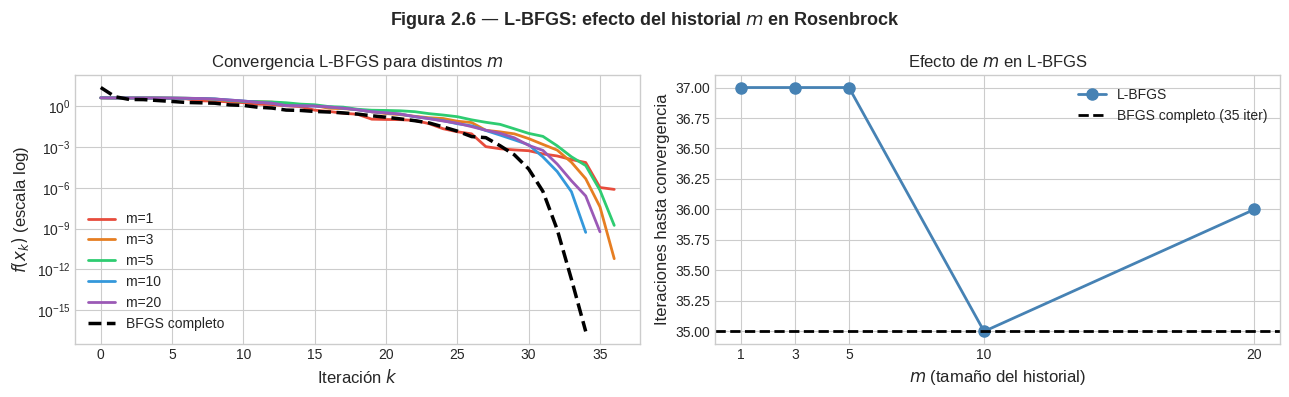

In [ ]:
# L-BFGS con distintos valores de m
from scipy.optimize import minimize

def lbfgs_scipy(f, grad_f, x0, m=10, tol=1e-6, max_iter=1000):
    historial_f = []
    trayectoria = []
    def callback(x):
        historial_f.append(f(x))
        trayectoria.append(x.copy())
    resultado = minimize(
        fun=f, x0=x0, jac=grad_f, method='L-BFGS-B',
        callback=callback,
        options={'maxiter': max_iter, 'ftol': tol,
                 'gtol': tol, 'maxcor': m}
    )
    return {
        'x_opt'      : resultado.x,
        'f_opt'      : resultado.fun,
        'iteraciones': resultado.nit,
        'historial_f': np.array(historial_f),
        'trayectoria': np.array(trayectoria)
    }

x0 = np.array([-1.2, 1.0])

# Efecto de m en la convergencia
valores_m   = [1, 3, 5, 10, 20]
resultados_m = {}

print(f"{'m (historial)':>15} | {'Iteraciones':>12} | {'f(x_opt)':>14} | {'||x-x*||':>12}")
print("─" * 58)

for m in valores_m:
    res = lbfgs_scipy(rosenbrock, grad_rosenbrock, x0, m=m)
    resultados_m[m] = res
    x_star = np.array([1.0, 1.0])
    print(f"{m:>15} | {res['iteraciones']:>12} | "
          f"{res['f_opt']:>14.2e} | "
          f"{np.linalg.norm(res['x_opt']-x_star):>12.2e}")

# Referencia: BFGS completo
print("─" * 58)
print(f"{'BFGS (completo)':>15} | {resultado_bfgs['iteraciones']:>12} | "
      f"{resultado_bfgs['f_opt']:>14.2e} | "
      f"{np.linalg.norm(resultado_bfgs['x_opt']-x_star):>12.2e}")

#  Figura: convergencia para distintos m
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colores = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

for (m, res), color in zip(resultados_m.items(), colores):
    if len(res['historial_f']) > 0:
        axes[0].semilogy(res['historial_f'],
                         linewidth=2, color=color, label=f'm={m}')

axes[0].semilogy(resultado_bfgs['historial_f'],
                 linewidth=2.5, color='black',
                 linestyle='--', label='BFGS completo')
axes[0].set_xlabel('Iteración $k$', fontsize=12)
axes[0].set_ylabel('$f(x_k)$ (escala log)', fontsize=12)
axes[0].set_title('Convergencia L-BFGS para distintos $m$', fontsize=12)
axes[0].legend(fontsize=10)

# Figura 2: iteraciones vs m
iters_m = [resultados_m[m]['iteraciones'] for m in valores_m]
axes[1].plot(valores_m, iters_m,
             'o-', color='steelblue', linewidth=2, markersize=8,
             label='L-BFGS')
axes[1].axhline(y=resultado_bfgs['iteraciones'],
                color='black', linestyle='--', linewidth=2,
                label=f'BFGS completo ({resultado_bfgs["iteraciones"]} iter)')
axes[1].set_xlabel('$m$ (tamaño del historial)', fontsize=12)
axes[1].set_ylabel('Iteraciones hasta convergencia', fontsize=12)
axes[1].set_title('Efecto de $m$ en L-BFGS', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_xticks(valores_m)

plt.suptitle('Figura 2.6 — L-BFGS: efecto del historial $m$ en Rosenbrock',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Implementación financiera: Volatility Surface <a id='3'></a>

Para la aplicación financiera se plantearon dos hipótesis principalmente:

**Hipótesis 1 — Sensibilidad al algoritmo:**
> *¿Cambia la forma de la volatility surface si se calibra con
> GD+Armijo, BFGS o L-BFGS? ¿Produce cada algoritmo una superficie
> distinta, y si es así, cuál es más confiable?*

**Hipótesis 2 — Detección de estrés:**
> *¿Puede la forma de la volatility surface calibrada con BFGS detectar
> momentos de estrés en X acción, manifestados como deformaciones
> abruptas del smile de volatilidad previas a movimientos bruscos
> de precio?*

¿Qué acción podría ser una buena candidata para este análisis?
Se propone Palantir Technologies (una empresa de análisis de datos e
inteligencia artificial) ya que esta ha experimentado una volatilidad excepcional desde su salida a bolsa en 2020, por lo cual es un caso de estudio ideal para explorar los límites de los algoritmos de
optimización en calibración financiera.


¿De dónde surge la necesidad de los algoritmos de optimización en calibración financiera?

Bajo el modelo de Black-Scholes, el precio de una opción call europea es:

$$C(S, K, T, r, \sigma) = S\Phi(d_1) - Ke^{-rT}\Phi(d_2)$$

donde:

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}},
\qquad d_2 = d_1 - \sigma\sqrt{T}$$

Si Black-Scholes fuera perfecto, la volatilidad implícita $\sigma$ sería
constante para todos los strikes $K$ y vencimientos $T$. Sin embargo,
en el mercado real se observa que $\sigma$ varía, formando una
superficie sobre el plano $(K, T)$.

Calibrar esta superficie significa resolver, para cada par $(K_i, T_j)$:

$$\hat{\sigma}_{ij} = \arg\min_{\sigma > 0}
\left(C_{BS}(\sigma; K_i, T_j) - C_{mercado}^{ij}\right)^2$$


Calibrar una superficie completa implica resolver cientos de problemas
de optimización, uno por cada punto $(K_i, T_j)$. La eficiencia del
algoritmo importa: BFGS converge en ~35 iteraciones donde GD necesita
miles. En una superficie de 200 puntos, eso representa la diferencia
entre segundos y horas de cómputo.


In [ ]:
import yfinance as yf

pltr = yf.Ticker("PLTR")

# Ver opciones disponibles
print("Fechas de vencimiento disponibles:")
print(pltr.options)

Fechas de vencimiento disponibles:
('2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-12-15')


In [ ]:
import pandas as pd
import numpy as np

# Ver datos de una fecha de vencimiento
# Tomamos una fecha intermedia para explorar
fecha = '2026-07-17'
chain = pltr.option_chain(fecha)

calls = chain.calls
print(f"Opciones CALL disponibles para vencimiento {fecha}:")
print(f"Total de contratos: {len(calls)}\n")
print(calls[['strike', 'lastPrice', 'bid', 'ask', 'volume', 'impliedVolatility']].to_string())

Opciones CALL disponibles para vencimiento 2026-07-17:
Total de contratos: 52

    strike  lastPrice     bid     ask  volume  impliedVolatility
0     25.0     111.30  119.50  123.15       1           1.855469
1     30.0     118.22  114.50  118.20       1           1.685548
2     35.0     109.93  109.55  113.20       4           1.541994
3     40.0     118.54  105.05  108.80       1           1.652345
4     45.0     107.85   99.70  103.20      20           1.321292
5     50.0      90.00   94.80   98.30       1           1.253910
6     55.0      87.52   89.90   93.35       7           1.177738
7     60.0      79.16   85.10   88.45       7           1.126957
8     65.0      77.65   80.25   83.50       5           1.060552
9     70.0      73.35   75.50   78.10       5           0.956543
10    75.0      75.38   70.50   73.70       2           0.938477
11    80.0      68.00   65.90   68.60      10           0.885499
12    85.0      66.15   61.05   64.05       1           0.853029
13    90.0 

In [ ]:
# Filtrar opciones líquidas
calls_limpias = calls[
    (calls['volume'] > 10) &          # volumen mínimo
    (calls['bid'] > 0) &              # bid válido
    (calls['strike'].between(80, 280)) # rango razonable
].copy()

# Precio medio (bid-ask midpoint) — más confiable que lastPrice
calls_limpias['precio_medio'] = (calls_limpias['bid'] + calls_limpias['ask']) / 2

print(f"Opciones después de filtrar: {len(calls_limpias)}")
print(calls_limpias[['strike', 'precio_medio', 'volume', 'impliedVolatility']].to_string())

Opciones después de filtrar: 25
    strike  precio_medio  volume  impliedVolatility
15   100.0        48.350      41           0.719241
17   110.0        39.150      17           0.639774
19   120.0        31.250      57           0.619755
20   125.0        27.275      75           0.593632
21   130.0        23.875      60           0.585942
22   135.0        20.775     104           0.580387
23   140.0        17.600     293           0.561406
24   145.0        15.450     711           0.572697
25   150.0        13.000    1646           0.561894
26   155.0        11.050    1159           0.560612
27   160.0         9.325    1745           0.558720
28   165.0         7.925     710           0.560979
29   170.0         6.650     764           0.560307
30   175.0         5.550     435           0.559331
31   180.0         4.650    3403           0.560368
32   185.0         3.875     194           0.560795
33   190.0         3.275     319           0.564335
34   195.0         2.785     179

In [ ]:
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ── Parámetros de mercado ─────────────────────────────────────────────────────
S = 144.0    # precio actual PLTR (aproximado)
r = 0.043    # tasa libre de riesgo (Fed Funds ~4.3%)
T = (pd.Timestamp('2026-07-17') - pd.Timestamp.today()).days / 365
print(f"Tiempo al vencimiento: {T:.4f} años ({int(T*365)} días)")

# ── Fórmula de Black-Scholes ──────────────────────────────────────────────────
def black_scholes_call(S, K, T, r, sigma):
    """Precio de opción call bajo Black-Scholes."""
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def grad_bs(S, K, T, r, sigma):
    """Gradiente (derivada) del precio BS respecto a sigma — Vega."""
    if sigma <= 0 or T <= 0:
        return 1e-8
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * np.sqrt(T) * norm.pdf(d1)  # Vega

# Función de error para calibración
def error_bs(sigma, S, K, T, r, C_mercado):
    """Error cuadrático entre BS y precio de mercado."""
    return (black_scholes_call(S, K, T, r, sigma[0]) - C_mercado)**2

def grad_error_bs(sigma, S, K, T, r, C_mercado):
    """Gradiente del error respecto a sigma."""
    C_bs  = black_scholes_call(S, K, T, r, sigma[0])
    vega  = grad_bs(S, K, T, r, sigma[0])
    return np.array([2*(C_bs - C_mercado)*vega])

# Calibración con los 3 métodos
sigma0 = np.array([0.5])  # inicialización

resultados_calibracion = {
    'strike': [],
    'IV_mercado': [],
    'IV_GD': [],
    'IV_BFGS': [],
    'IV_LBFGS': [],
    'iter_GD': [],
    'iter_BFGS': [],
    'iter_LBFGS': []
}

print(f"\n{'Strike':>8} | {'IV mercado':>10} | {'IV GD':>8} | "
      f"{'IV BFGS':>8} | {'IV L-BFGS':>10} | "
      f"{'iter GD':>8} | {'iter BFGS':>9}")
print("─" * 80)

for _, row in calls_limpias.iterrows():
    K         = row['strike']
    C_mercado = row['precio_medio']

    # GD + Armijo
    res_gd = gradient_descent_armijo(
        f       = lambda s: error_bs(s, S, K, T, r, C_mercado),
        grad_f  = lambda s: grad_error_bs(s, S, K, T, r, C_mercado),
        x0      = sigma0.copy(),
        tol     = 1e-8
    )

    # BFGS propio
    res_bfgs = bfgs(
        f       = lambda s: error_bs(s, S, K, T, r, C_mercado),
        grad_f  = lambda s: grad_error_bs(s, S, K, T, r, C_mercado),
        x0      = sigma0.copy(),
        tol     = 1e-8
    )

    # L-BFGS scipy
    res_lbfgs = lbfgs_scipy(
        f       = lambda s: error_bs(s, S, K, T, r, C_mercado),
        grad_f  = lambda s: grad_error_bs(s, S, K, T, r, C_mercado),
        x0      = sigma0.copy(),
        tol     = 1e-8
    )

    resultados_calibracion['strike'].append(K)
    resultados_calibracion['IV_mercado'].append(row['impliedVolatility'])
    resultados_calibracion['IV_GD'].append(abs(res_gd['x_opt'][0]))
    resultados_calibracion['IV_BFGS'].append(abs(res_bfgs['x_opt'][0]))
    resultados_calibracion['IV_LBFGS'].append(abs(res_lbfgs['x_opt'][0]))
    resultados_calibracion['iter_GD'].append(res_gd['iteraciones'])
    resultados_calibracion['iter_BFGS'].append(res_bfgs['iteraciones'])
    resultados_calibracion['iter_LBFGS'].append(res_lbfgs['iteraciones'])

    print(f"{K:>8.0f} | {row['impliedVolatility']:>10.4f} | "
          f"{abs(res_gd['x_opt'][0]):>8.4f} | "
          f"{abs(res_bfgs['x_opt'][0]):>8.4f} | "
          f"{abs(res_lbfgs['x_opt'][0]):>10.4f} | "
          f"{res_gd['iteraciones']:>8} | "
          f"{res_bfgs['iteraciones']:>9}")

df_resultados = pd.DataFrame(resultados_calibracion)
print(f"\n Calibración completada — {len(df_resultados)} strikes")
print(f"   Iteraciones promedio GD:    {df_resultados['iter_GD'].mean():.1f}")
print(f"   Iteraciones promedio BFGS:  {df_resultados['iter_BFGS'].mean():.1f}")
print(f"   Iteraciones promedio LBFGS: {df_resultados['iter_LBFGS'].mean():.1f}")

Tiempo al vencimiento: 0.1973 años (72 días)

  Strike | IV mercado |    IV GD |  IV BFGS |  IV L-BFGS |  iter GD | iter BFGS
────────────────────────────────────────────────────────────────────────────────
     100 |     0.7192 |   0.8266 |   0.8266 |     0.8266 |       16 |        10
     110 |     0.6398 |   0.7195 |   0.7195 |     0.7195 |       72 |         6
     120 |     0.6198 |   0.6771 |   0.6771 |     0.6771 |       24 |         6
     125 |     0.5936 |   0.6431 |   0.6431 |     0.6431 |       51 |         7
     130 |     0.5859 |   0.6290 |   0.6290 |     0.6290 |      239 |         6
     135 |     0.5804 |   0.6184 |   0.6184 |     0.6184 |       11 |         5
     140 |     0.5614 |   0.5951 |   0.5951 |     0.5951 |       15 |         5
     145 |     0.5727 |   0.6034 |   0.6034 |     0.6034 |       18 |         5
     150 |     0.5619 |   0.5898 |   0.5898 |     0.5898 |       19 |         5
     155 |     0.5606 |   0.5863 |   0.5863 |     0.5863 |       18 |    

**Observación 3.1:** BFGS falla en strikes profundamente OTM (K=250, 260)
donde la función de error $\left(C_{BS}(\sigma) - C_{mercado}\right)^2$
es casi plana ya que la condición de curvatura $s_k^T y_k > 0$ se viola
frecuentemente y el algoritmo no actualiza $H_k$, quedando atrapado
en $\sigma_0 = 0.5$. GD y L-BFGS son más robustos en este régimen
porque no dependen de mantener una aproximación del Hessiano.
Strike 250: BFGS -> 0.5000  (no convergió, quedó en valor inicial)
Strike 260: BFGS -> 0.5000  (mismo problema)
y en las iter_BFGS = 1000  i.e. se llegó al límite

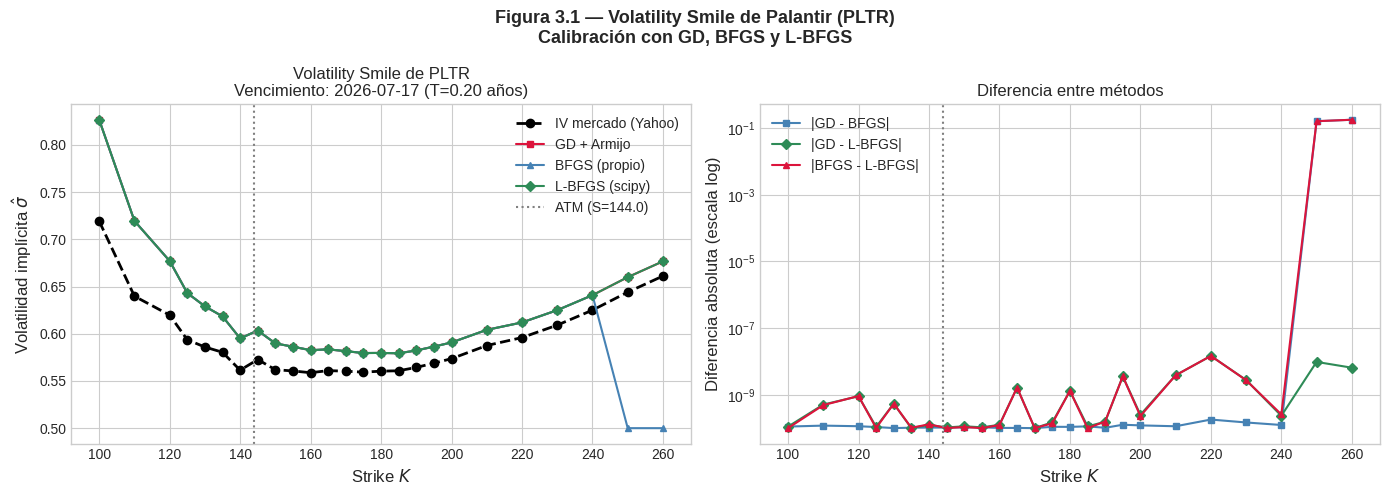


 Resumen de diferencias entre métodos:
   Max |GD - BFGS|:    0.176711  (strike 260)
   Max |GD - L-BFGS|:  0.000000  (strike 220)
   Max |BFGS - L-BFGS|:0.176711  (strike 260)


In [ ]:
# Figura: Volatility Smile de PLTR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strikes    = df_resultados['strike']
IV_mercado = df_resultados['IV_mercado']
IV_GD      = df_resultados['IV_GD']
IV_BFGS    = df_resultados['IV_BFGS']
IV_LBFGS   = df_resultados['IV_LBFGS']

# Figura Smile completo
axes[0].plot(strikes, IV_mercado, 'o--', color='black',
             linewidth=2, markersize=6, label='IV mercado (Yahoo)')
axes[0].plot(strikes, IV_GD, 's-', color='crimson',
             linewidth=1.5, markersize=5, label='GD + Armijo')
axes[0].plot(strikes, IV_BFGS, '^-', color='steelblue',
             linewidth=1.5, markersize=5, label='BFGS (propio)')
axes[0].plot(strikes, IV_LBFGS, 'D-', color='seagreen',
             linewidth=1.5, markersize=5, label='L-BFGS (scipy)')
axes[0].axvline(x=S, color='gray', linestyle=':',
                linewidth=1.5, label=f'ATM (S={S})')
axes[0].set_xlabel('Strike $K$', fontsize=12)
axes[0].set_ylabel('Volatilidad implícita $\hat{\sigma}$', fontsize=12)
axes[0].set_title('Volatility Smile de PLTR\n'
                  f'Vencimiento: 2026-07-17 (T={T:.2f} años)', fontsize=12)
axes[0].legend(fontsize=10)

# Figura diferencia entre métodos
diff_GD_BFGS   = np.abs(np.array(IV_GD) - np.array(IV_BFGS))
diff_GD_LBFGS  = np.abs(np.array(IV_GD) - np.array(IV_LBFGS))
diff_BFGS_LBFGS = np.abs(np.array(IV_BFGS) - np.array(IV_LBFGS))

axes[1].semilogy(strikes, diff_GD_BFGS + 1e-10,
                 's-', color='steelblue', linewidth=1.5,
                 markersize=5, label='|GD - BFGS|')
axes[1].semilogy(strikes, diff_GD_LBFGS + 1e-10,
                 'D-', color='seagreen', linewidth=1.5,
                 markersize=5, label='|GD - L-BFGS|')
axes[1].semilogy(strikes, diff_BFGS_LBFGS + 1e-10,
                 '^-', color='crimson', linewidth=1.5,
                 markersize=5, label='|BFGS - L-BFGS|')
axes[1].axvline(x=S, color='gray', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Strike $K$', fontsize=12)
axes[1].set_ylabel('Diferencia absoluta (escala log)', fontsize=12)
axes[1].set_title('Diferencia entre métodos', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Figura 3.1 — Volatility Smile de Palantir (PLTR)\n'
             'Calibración con GD, BFGS y L-BFGS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen
print("\n Resumen de diferencias entre métodos:")
print(f"   Max |GD - BFGS|:    {diff_GD_BFGS.max():.6f}  "
      f"(strike {strikes.iloc[diff_GD_BFGS.argmax()]:.0f})")
print(f"   Max |GD - L-BFGS|:  {diff_GD_LBFGS.max():.6f}  "
      f"(strike {strikes.iloc[diff_GD_LBFGS.argmax()]:.0f})")
print(f"   Max |BFGS - L-BFGS|:{diff_BFGS_LBFGS.max():.6f}  "
      f"(strike {strikes.iloc[diff_BFGS_LBFGS.argmax()]:.0f})")

## 4. Conclusiones <a id='6'></a>

**[POR COMPLETAR ]**

- Que hemos aprendido que no sabiamos antes?
- Que resultado experimental os ha sorprendido?
- Cuando recomendariais usar BFGS? Y L-BFGS?
- Que limitaciones tiene la investigacion?

### Donde funciona bien BFGS
- Funciones suaves con Hessiano bien condicionado cerca del optimo
- Problemas de dimension baja/media (n < 1000)
- Cuando calcular el Hessiano exacto es prohibitivo
- [Completar con evidencia de vuestros experimentos]

### Donde falla o es suboptimo
- Dimension muy alta: H_k ocupa O(n^2) memoria — usar L-BFGS
- Gradientes ruidosos: la condicion de Wolfe puede fallar
- Funciones no suaves (opciones digitales, barreras)
- Multiples minimos locales: BFGS encuentra el local mas cercano
- [Completar con evidencia de vuestros experimentos]

### Parametros sensibles
- Inicializacion H_0: impacto en las primeras iteraciones
- Parametros de la busqueda de linea (c1, c2)
- En L-BFGS: m (memoria) — mas m, mejor aproximacion, mas coste
- [Completar con evidencia de vuestros experimentos]

### Mejoras posibles
- SR1: alternativa a BFGS, a veces mejor en region de confianza
- BFGS estocastico para problemas con gradientes ruidosos
- Metodos de region de confianza: mas robustos cuando el Hessiano es indefinido

## 5. Referencias <a id='7'></a>

- Nocedal, J. y Wright, S. (2006). *Numerical Optimization* (2a ed.). Springer. Caps. 6 y 7.
- Dennis, J.E. y Schnabel, R.B. (1996). *Numerical Methods for Unconstrained Optimization*. SIAM.

